# Cancer Support Netherlands – Patient Navigator

## Project Overview

Cancer Support Netherlands (CSN) supports English-speaking cancer patients, survivors, and caregivers in the Netherlands.

Finding the right healthcare information can be difficult for international patients. Information is often spread across different websites and mainly written in Dutch. It can therefore be hard to understand what to do next, who to contact, or where to find support.

The goal of this project is to help CSN prepare a future Patient Navigator. It should give patients clear and reliable information in English and help them understand the Dutch healthcare system.

Our first focus is **Orientation**. This covers:
- how the Dutch healthcare system works;
- the role of GPs, specialists, hospitals, and insurers;
- referrals and access to care;
- health insurance;
- patient rights and second opinions;
- trusted information and support.

## Goal of this Notebook

In this notebook, we collect useful information from trusted Dutch healthcare websites. We then clean, translate, and organise the data.

The goal is to create a clear and structured dataset that CSN can later use for its Patient Navigator.

## 1. Data Collection and Web Scraping

The first step is to collect useful information from trusted Dutch healthcare websites.

We only use approved sources that are relevant to the CSN project. The goal is to keep the original text, source, links, and basic information about each page.

In [ ]:
# Install the Python libraries.

!pip install requests beautifulsoup4 pandas lxml

In [3]:
# Import libraries.

import requests
import pandas as pd
import time
import hashlib

from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
from urllib.robotparser import RobotFileParser
from datetime import datetime

In [4]:
# Create the approved source register.

approved_sources = [
    {"source": "Kanker.nl Information",
        "url": "https://www.kanker.nl/informatie" },
    {"source": "Rijksoverheid",
        "url": "https://www.rijksoverheid.nl/onderwerpen/zorgverzekering"},
    {"source": "Thuisarts",
        "url": "https://www.thuisarts.nl/"},
    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/"},
    {"source": "NFK",
        "url": "https://nfk.nl/"},
    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/"},
    {"source": "AVL",
        "url": "https://www.avl.nl/verwijzers/"},
    {"source": "IKNL",
        "url": "https://iknl.nl/"},
    {"source": "Zorgwijzer",
        "url": "https://www.zorgwijzer.nl/zorgwijzers/kanker"}]

sources_df = pd.DataFrame(approved_sources)
sources_df

,source,url
0,Kanker.nl Information,https://www.kanker.nl/informatie
1,Rijksoverheid,https://www.rijksoverheid.nl/onderwerpen/zorgv...
2,Thuisarts,https://www.thuisarts.nl/
3,Zorginstituut Nederland,https://www.zorginstituutnederland.nl/
4,NFK,https://nfk.nl/
5,Kanker.nl,https://www.kanker.nl/
6,AVL,https://www.avl.nl/verwijzers/
7,IKNL,https://iknl.nl/
8,Zorgwijzer,https://www.zorgwijzer.nl/zorgwijzers/kanker


In [5]:
# Create a respectful request configuration.

BOT_NAME = "CSNResearchBot"

HEADERS = {
    "User-Agent": "CSNResearchBot/1.0 - academic project for Cancer Support Netherlands"}

REQUEST_DELAY = 2

### Responsible Web Scraping

Before collecting data, we check if each website allows automated access through its `robots.txt` file.

We also add a short delay between requests. This helps us collect the data in a respectful way without sending too many requests to the websites.

In [6]:
# Add a robots.txt check.

def check_robots(url):
    parsed = urlparse(url)

    robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"

    try:
        response = requests.get(
            robots_url,
            headers=HEADERS,
            timeout=10)

        if response.status_code != 200:
            return None

        rp = RobotFileParser()
        rp.set_url(robots_url)
        rp.parse(response.text.splitlines())

        return rp.can_fetch(BOT_NAME, url)

    except requests.RequestException:
        return None

In [7]:
# Test example.

test_url = "https://www.rijksoverheid.nl/onderwerpen/zorgverzekering"

check_robots(test_url)

True

### Building the Scraper

The scraper collects the main content from each webpage.

It keeps useful elements such as titles, paragraphs, lists, and hyperlinks. It also removes website elements that are not useful for the project, such as menus, scripts, and footers.

Each piece of information is stored with its original source and URL so it can be checked later.

In [8]:
# Build the actual scraping function.

def scrape_page(url, source_name):

    print(f"Scraping: {url}")

    response = requests.get(
        url,
        headers=HEADERS,
        timeout=20)

    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")

# Page title.
    if soup.title:
        page_title = soup.title.get_text(strip=True)
    else:
        page_title = ""

# Try to isolate the main content.
    main = soup.find("main")

    if main is None:
        main = soup.find("article")

    if main is None:
        main = soup.body

# Remove content that is normally irrelevant.
    for tag in main.find_all(
        ["script", "style", "nav", "footer", "form", "noscript"]):
        tag.decompose()

    rows = []

    current_heading = ""
    content_order = 0

    for element in main.find_all(
        ["h1", "h2", "h3", "h4", "p", "li"]):

        text = element.get_text(
            " ",
            strip=True)

        if not text:
            continue

        tag_name = element.name

# Keep track of the current section.
        if tag_name in ["h1", "h2", "h3", "h4"]:
            current_heading = text

# Extract hyperlinks inside this block.
        links = []

        for link in element.find_all("a", href=True):

            absolute_url = urljoin(
                url,
                link["href"])

            link_text = link.get_text(
                " ",
                strip=True)

            links.append({
                "text": link_text,
                "url": absolute_url})

        hyperlink_text = " | ".join(
            link["text"] for link in links)

        hyperlink_url = " | ".join(
            link["url"] for link in links)

        content_order += 1

        rows.append({
    "source_organisation": source_name,
    "source_page_title": page_title,
    "original_url": url,
    "scrape_date": datetime.now().strftime("%Y-%m-%d"),

    "patient_journey_stage": "",
    "question_or_topic": "",
    "stakeholder": "",
    "action_next_step": "",

    "original_dutch_text": text,
    "english_translation": "",
    "summary_answer_text": "",
    "priority_relevance_flag": "",

    "hyperlink_text": hyperlink_text,
    "hyperlink_url": hyperlink_url})

    time.sleep(REQUEST_DELAY)

    return rows

### Testing the Scraper

Before using the scraper on all selected pages, we test it on one Rijksoverheid page.

This allows us to check that the content and links are collected correctly before moving to the full data collection.

In [9]:
# Testing it on one page first.

rows = scrape_page(
    url="https://www.rijksoverheid.nl/onderwerpen/zorgverzekering",
    source_name="Rijksoverheid")

df = pd.DataFrame(rows)

df.head()

Scraping: https://www.rijksoverheid.nl/onderwerpen/zorgverzekering


,source_organisation,source_page_title,original_url,scrape_date,patient_journey_stage,question_or_topic,stakeholder,action_next_step,original_dutch_text,english_translation,summary_answer_text,priority_relevance_flag,hyperlink_text,hyperlink_url
0,Rijksoverheid,Zorgverzekering | Rijksoverheid.nl,https://www.rijksoverheid.nl/onderwerpen/zorgv...,2026-09-06,,,,,Uitgelicht,,,,,
1,Rijksoverheid,Zorgverzekering | Rijksoverheid.nl,https://www.rijksoverheid.nl/onderwerpen/zorgv...,2026-09-06,,,,,Past uw zorgverzekering nog bij u? Bekijk een ...,,,,Past uw zorgverzekering nog bij u? Bekijk een ...,https://www.rijksoverheid.nl/documenten/videos...
2,Rijksoverheid,Zorgverzekering | Rijksoverheid.nl,https://www.rijksoverheid.nl/onderwerpen/zorgv...,2026-09-06,,,,,Past uw zorgverzekering nog bij u?,,,,,
3,Rijksoverheid,Zorgverzekering | Rijksoverheid.nl,https://www.rijksoverheid.nl/onderwerpen/zorgv...,2026-09-06,,,,,Bekijk een video over de zorgverzekering voor ...,,,,,
4,Rijksoverheid,Zorgverzekering | Rijksoverheid.nl,https://www.rijksoverheid.nl/onderwerpen/zorgv...,2026-09-06,,,,,Information in other languages Op government.n...,,,,Information in other languages Op government.n...,https://www.government.nl/documents/publicatio...


In [10]:
# Checking what was extracted.

print("Rows:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst Dutch text blocks:")

for text in df["original_dutch_text"].head(10):
    print(text)
    print("-" * 50)

Rows: 17

Columns:
['source_organisation', 'source_page_title', 'original_url', 'scrape_date', 'patient_journey_stage', 'question_or_topic', 'stakeholder', 'action_next_step', 'original_dutch_text', 'english_translation', 'summary_answer_text', 'priority_relevance_flag', 'hyperlink_text', 'hyperlink_url']

First Dutch text blocks:
Uitgelicht
--------------------------------------------------
Past uw zorgverzekering nog bij u? Bekijk een video over de zorgverzekering voor 2025. Waar moet u aan denken? Bijvoorbeeld als u overstapt naar een andere zorgverzekeraar. Beeld: © Ministerie van Volksgezondheid, Welzijn en Sport / In Between, Inclusia, Ministerie van Volksgezondheid, Welzijn en Sport Lees verder
--------------------------------------------------
Past uw zorgverzekering nog bij u?
--------------------------------------------------
Bekijk een video over de zorgverzekering voor 2025. Waar moet u aan denken? Bijvoorbeeld als u overstapt naar een andere zorgverzekeraar.
--------------

### Selecting the Pages

We selected pages that cover the main topics of the patient journey.

These include diagnosis, healthcare roles, referrals, insurance, patient rights, second opinions, and support.

Each page is linked to a patient journey stage and a topic before the data is collected.

In [11]:
# There are 29 targeted pages to scrape.

pages_to_scrape = [

# 1. Kanker.nl - Diagnosis and treatment pathways.

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/diagnose",
        "journey_stage": "Diagnosis",
        "topic": "Diagnosis and what happens next"},

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/algemene-onderwerpen/onderzoeken-bij-kanker/welke-onderzoeken/onderzoeken-als-je-misschien-kanker-hebt",
        "journey_stage": "Diagnosis",
        "topic": "Diagnostic investigations and referral"},

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-voor-de-diagnose",
        "journey_stage": "Diagnosis",
        "topic": "Discussing diagnosis with healthcare professional"},

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-over-de-behandeling",
        "journey_stage": "Treatment",
        "topic": "Treatment planning and shared decision-making"},

# 2. Rijksoverheid - Healthcare system and insurance.

    {"source": "Rijksoverheid",
        "url": "https://www.rijksoverheid.nl/onderwerpen/zorgverzekering",
        "journey_stage": "Orientation",
        "topic": "Dutch health insurance"},

    {"source": "Rijksoverheid",
        "url": "https://www.rijksoverheid.nl/themas/familie-zorg-en-gezondheid/zorgverzekering/zorgverzekeringsstelsel-in-nederland",
        "journey_stage": "Orientation",
        "topic": "How the Dutch health insurance system works"},

    {"source": "Rijksoverheid",
        "url": "https://www.rijksoverheid.nl/vraag-en-antwoord/zorgverzekering/wat-zit-er-in-het-basispakket-van-de-zorgverzekering",
        "journey_stage": "Orientation",
        "topic": "Basic health insurance coverage"},

    {"source": "Rijksoverheid",
        "url": "https://www.rijksoverheid.nl/vraag-en-antwoord/zorgverzekering/eigen-risico-zorgverzekering",
        "journey_stage": "Orientation",
        "topic": "Health insurance deductible"},

# 3. Thuisarts - Referrals and system navigation.

    {"source": "Thuisarts",
        "url": "https://www.thuisarts.nl/inschrijven-bij-huisarts",
        "journey_stage": "Orientation",
        "topic": "Choosing and registering with a GP"},

    {"source": "Thuisarts",
        "url": "https://www.thuisarts.nl/met-wie-krijg-je-te-maken-bij-huisartsenpraktijk",
        "journey_stage": "Orientation",
        "topic": "GP role and referrals to specialist care"},

    {"source": "Thuisarts",
        "url": "https://www.thuisarts.nl/rechten-en-plichten-van-pati%C3%ABnten",
        "journey_stage": "Orientation",
        "topic": "Patient rights and responsibilities"},

# 4. Zorginstituut Nederland - Coverage and costs.

    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/verzekerde-zorg/z/zvw-algemeen-hoe-werkt-de-zorgverzekeringswet",
        "journey_stage": "Orientation",
        "topic": "How the Health Insurance Act works"},

    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/verzekerde-zorg/b/basispakket-zorgverzekeringswet-zvw",
        "journey_stage": "Orientation",
        "topic": "Basic insurance package"},

    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/verzekerde-zorg/m/medisch-specialistische-zorg-zvw",
        "journey_stage": "Orientation",
        "topic": "Specialist care, referrals and coverage"},

    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/verzekerde-zorg/e/eigen-risico-zvw",
        "journey_stage": "Orientation",
        "topic": "Deductible and expected costs"},

    {"source": "Zorginstituut Nederland",
        "url": "https://www.zorginstituutnederland.nl/verzekerde-zorg/e/eigen-bijdrage-zvw",
        "journey_stage": "Orientation",
        "topic": "Patient co-payments"},

# 5. NFK - Patient advocacy and second opinions.

    {"source": "NFK",
        "url": "https://nfk.nl/organisatie/voor-pati%C3%ABnten",
        "journey_stage": "Orientation",
        "topic": "Patient organisations and advocacy"},

    {"source": "NFK",
        "url": "https://nfk.nl/inzichten/webinars/een-ziekenhuis-kiezen-hoe-belangrijk-is-dat",
        "journey_stage": "Orientation",
        "topic": "Hospital choice and second opinion"},

    {"source": "NFK",
        "url": "https://nfk.nl/themas/samen-beslissen/visie",
        "journey_stage": "Treatment",
        "topic": "Shared decision-making and patient voice"},

# 6. Kanker.nl - Immediate next steps.

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/gevolgen-van-kanker/kanker-wat-nu/diagnose-kanker/kanker-wat-nu",
        "journey_stage": "Diagnosis",
        "topic": "Immediate next steps after cancer diagnosis"},

# 7. AVL - Hospital process and points of contact.

    {"source": "Antoni van Leeuwenhoek",
        "url": "https://www.avl.nl/verwijzers/",
        "journey_stage": "Orientation",
        "topic": "Hospital referral process"},

    {"source": "Antoni van Leeuwenhoek",
        "url": "https://www.avl.nl/afspraak-maken/",
        "journey_stage": "Referral and Access",
        "topic": "Making a hospital appointment after referral"},

    {"source": "Antoni van Leeuwenhoek",
        "url": "https://www.avl.nl/voorbereiding-afspraak/second-opinion/",
        "journey_stage": "Treatment",
        "topic": "Second opinion process"},

    {"source": "Antoni van Leeuwenhoek",
        "url": "https://www.avl.nl/voorbereiding-afspraak/voorbereiding-en-eerste-afspraak/uw-rechten-en-plichten-als-patient/",
        "journey_stage": "Orientation",
        "topic": "Patient rights"},

  
# 8. IKNL - Organisation and responsibility for care.

    {"source": "IKNL",
        "url": "https://iknl.nl/netwerkzorg",
        "journey_stage": "Orientation",
        "topic": "Organisation of oncology care"},

    {"source": "IKNL",
        "url": "https://iknl.nl/kanker-en-leven/oncologiezorgnetwerken",
        "journey_stage": "Orientation",
        "topic": "Roles within oncology care networks"},

    {"source": "IKNL",
        "url": "https://iknl.nl/kanker-en-leven/zorgaanbod/verwijsgids-kanker",
        "journey_stage": "Support",
        "topic": "Finding specialist and supportive care"},

# 9. Kanker.nl - Support during treatment.

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/hulp-en-ondersteuning",
        "journey_stage": "Treatment",
        "topic": "Support during and after treatment"},

    {"source": "Kanker.nl",
        "url": "https://www.kanker.nl/gevolgen-van-kanker/kanker-wat-nu/diagnose-kanker/hulp-bij-kanker",
        "journey_stage": "Treatment",
        "topic": "Practical and supportive cancer care"},

# 10. Zorgwijzer - Journey overview and insurance.

    {"source": "Zorgwijzer",
        "url": "https://www.zorgwijzer.nl/zorgwijzers/kanker",
        "journey_stage": "Orientation",
        "topic": "Cancer journey and insurance in practice"}]


### Collecting the Data

We now run the scraper on all selected pages.

For each page, the code checks if scraping is allowed, collects the available content, and adds the patient journey stage and topic.

All results are then combined into one dataset.

In [12]:
# Create an empty list to collect scraped rows from all selected webpages.

all_rows = []

for page in pages_to_scrape:

    source_name = page["source"]
    url = page["url"]

    print("=" * 70)
    print(f"Checking: {source_name}")
    print(url)

    allowed = check_robots(url)

    if allowed is False:
        print("Blocked by robots.txt. Skipping.")
        continue

    try:
        rows = scrape_page(
            url=url,
            source_name=source_name)

        for row in rows:
            row["patient_journey_stage"] = page["journey_stage"]
            row["question_or_topic"] = page["topic"]

        all_rows.extend(rows)

        print(f"Successfully extracted {len(rows)} rows.")

    except Exception as e:
        print(f"Error scraping {url}")
        print(e)

Checking: Kanker.nl
https://www.kanker.nl/diagnose
Scraping: https://www.kanker.nl/diagnose
Successfully extracted 3 rows.
Checking: Kanker.nl
https://www.kanker.nl/algemene-onderwerpen/onderzoeken-bij-kanker/welke-onderzoeken/onderzoeken-als-je-misschien-kanker-hebt
Scraping: https://www.kanker.nl/algemene-onderwerpen/onderzoeken-bij-kanker/welke-onderzoeken/onderzoeken-als-je-misschien-kanker-hebt
Successfully extracted 37 rows.
Checking: Kanker.nl
https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-voor-de-diagnose
Scraping: https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-voor-de-diagnose
Successfully extracted 64 rows.
Checking: Kanker.nl
https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-over-de-behandeling
Scraping: https://www.kanker.nl/algemene-onderwerpen/in-gesprek-met-je-arts/algemeen/in-gesprek-met-je-arts-over-de-behandeling
Success

In [13]:
# Convert all scraped rows into one combined DataFrame and preview the results.

csn_df = pd.DataFrame(all_rows)

print("Total rows:", len(csn_df))

csn_df.head()

Total rows: 1488


,source_organisation,source_page_title,original_url,scrape_date,patient_journey_stage,question_or_topic,stakeholder,action_next_step,original_dutch_text,english_translation,summary_answer_text,priority_relevance_flag,hyperlink_text,hyperlink_url
0,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,"Diagnose kanker, hoe nu verder?",,,,,
1,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,"Wanneer je de diagnose kanker krijgt, is dat e...",,,,,
2,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,In deze heftige tijd is het fijn om wat houvas...,,,,,
3,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,,,Onderzoeken als je misschien kanker hebt,,,,,
4,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,,,Deze informatie is gecontroleerd door deskundi...,,,,,


### Data Collection Results

The scraping process collected 1,480 rows of Dutch healthcare information.

Most selected pages were successfully scraped. One page returned no content and may need to be reviewed separately.

The next step is to clean the collected data before translation and analysis.

In [14]:
# Create a backup of the raw scraped dataset before cleaning.

csn_raw_df = csn_df.copy()

# Standardise whitespace in the original Dutch text.
csn_df["original_dutch_text"] = (
    csn_df["original_dutch_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip())

print("Rows before cleaning:", len(csn_raw_df))
print("Rows after text standardisation:", len(csn_df))

Rows before cleaning: 1488
Rows after text standardisation: 1488


## 2. Data Cleaning

The scraped data can contain repeated text, empty rows, or website elements that are not useful for patients.

We clean the dataset before translation. This helps us keep only useful healthcare information and avoids translating unnecessary content.

In [15]:
# Remove rows where no meaningful Dutch text was extracted.

csn_df = csn_df[
    csn_df["original_dutch_text"] != ""
].copy()

print("Rows remaining after removing empty text:", len(csn_df))

Rows remaining after removing empty text: 1488


In [16]:
# Remove duplicate text extracted from the same webpage.

rows_before = len(csn_df)

csn_df = csn_df.drop_duplicates(
    subset=[
        "source_organisation",
        "original_url",
        "original_dutch_text"]
).copy()

rows_after = len(csn_df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before duplicate removal: 1488
Rows after duplicate removal: 1421
Duplicates removed: 67


In [17]:
# Remove obvious website-navigation and interface text.

boilerplate_terms = [
    "menu",
    "zoeken",
    "zoek",
    "inloggen",
    "login",
    "home",
    "privacy",
    "privacyverklaring",
    "cookie",
    "cookies",
    "cookie instellingen",
    "nieuwsbrief",
    "contact",
    "facebook",
    "instagram",
    "linkedin",
    "youtube"]

csn_df = csn_df[
    ~csn_df["original_dutch_text"]
    .str.lower()
    .isin(boilerplate_terms)
].copy()

print("Rows remaining after removing obvious website noise:", len(csn_df))

Rows remaining after removing obvious website noise: 1407


In [18]:
# Reset the DataFrame index after cleaning.

csn_df = csn_df.reset_index(drop=True)

csn_df.head()

,source_organisation,source_page_title,original_url,scrape_date,patient_journey_stage,question_or_topic,stakeholder,action_next_step,original_dutch_text,english_translation,summary_answer_text,priority_relevance_flag,hyperlink_text,hyperlink_url
0,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,"Diagnose kanker, hoe nu verder?",,,,,
1,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,"Wanneer je de diagnose kanker krijgt, is dat e...",,,,,
2,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,,,In deze heftige tijd is het fijn om wat houvas...,,,,,
3,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,,,Onderzoeken als je misschien kanker hebt,,,,,
4,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,,,Deze informatie is gecontroleerd door deskundi...,,,,,


### Quality Check

After cleaning, we review the dataset to check how much information was collected from each source.

We also look at a sample of the Dutch text to identify any remaining website content that should be removed.

In [19]:
# Check the amount of cleaned content collected from each source organisation.

csn_df["source_organisation"].value_counts()

source_organisation
Zorginstituut Nederland    422
Kanker.nl                  230
Antoni van Leeuwenhoek     205
Zorgwijzer                 155
Rijksoverheid              116
IKNL                       112
Thuisarts                  101
NFK                         66
Name: count, dtype: int64

In [20]:
# Preview a sample of cleaned Dutch text.

for text in csn_df["original_dutch_text"].head(20):
    print(text)
    print("-" * 70)

Diagnose kanker, hoe nu verder?
----------------------------------------------------------------------
Wanneer je de diagnose kanker krijgt, is dat een enorme schok. Er komt in korte tijd veel op je af. Je probeert in beeld te krijgen wat je precies hebt, welke onderzoeken nodig zijn en welke behandelingen je straks kunt krijgen.
----------------------------------------------------------------------
In deze heftige tijd is het fijn om wat houvast te hebben. Daarom vind je hier meer informatie, tips en hulp voor als je net de diagnose gehad hebt.
----------------------------------------------------------------------
Onderzoeken als je misschien kanker hebt
----------------------------------------------------------------------
Deze informatie is gecontroleerd door deskundigen.
----------------------------------------------------------------------
Delen
----------------------------------------------------------------------
Je hebt klachten en daarom stuurt de huisarts je door naar het zie

### Final Cleaning Check

The first review showed that a few non-informative website elements were still present.

We remove these remaining elements before saving the cleaned dataset.

In [21]:
# Remove additional non-informative webpage text identified during quality control.

additional_noise = [
    "delen",
    "lees op deze pagina over:",
    "deze informatie is gecontroleerd door deskundigen."]

rows_before = len(csn_df)

csn_df = csn_df[
    ~csn_df["original_dutch_text"]
    .str.lower()
    .isin(additional_noise)
].copy()

csn_df = csn_df.reset_index(drop=True)

print("Rows before additional cleaning:", rows_before)
print("Rows after additional cleaning:", len(csn_df))
print("Additional rows removed:", rows_before - len(csn_df))

Rows before additional cleaning: 1407
Rows after additional cleaning: 1390
Additional rows removed: 17


### Saving the Cleaned Dataset

The cleaned Dutch dataset is saved before translation.

This gives us a clear version of the original source data that can be used in the next stage of the project.

In [22]:
# Save the cleaned scraped dataset before translation and further analysis.

csn_df.to_csv(
    "CSN_cleaned_Dutch_dataset.csv",
    index=False,
    encoding="utf-8-sig")

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 3. Translation

The next step is to translate the cleaned data from Dutch into English.

This is important because the Patient Navigator is made for English-speaking patients. We will use Python to translate the content while keeping the original Dutch text in the dataset.

We will also check some translations to make sure that important healthcare and medical terms keep the correct meaning.

In [ ]:
# Install the translation library.

!pip install deep-translator

In [24]:
# Import the translator.

from deep_translator import GoogleTranslator

### Testing the Translation

Before translating the full dataset, we test the method on a small sample.

This helps us check that the translation works correctly and that the English text is stored in the right column.

In [25]:
# Create the Dutch to English translator.

translator = GoogleTranslator(
    source="nl",
    target="en")

# Test the translator on the first five rows.

test_texts = csn_df["original_dutch_text"].head(5).tolist()

test_translations = [
    translator.translate(text)
    for text in test_texts]

for dutch, english in zip(test_texts, test_translations):
    print("Dutch:")
    print(dutch)
    print("\nEnglish:")
    print(english)
    print("-" * 70)

Dutch:
Diagnose kanker, hoe nu verder?

English:
Cancer diagnosis, what next?
----------------------------------------------------------------------
Dutch:
Wanneer je de diagnose kanker krijgt, is dat een enorme schok. Er komt in korte tijd veel op je af. Je probeert in beeld te krijgen wat je precies hebt, welke onderzoeken nodig zijn en welke behandelingen je straks kunt krijgen.

English:
When you are diagnosed with cancer, it is a huge shock. A lot comes at you in a short time. You try to get an idea of ​​what exactly you have, what tests are needed and what treatments you can receive later.
----------------------------------------------------------------------
Dutch:
In deze heftige tijd is het fijn om wat houvast te hebben. Daarom vind je hier meer informatie, tips en hulp voor als je net de diagnose gehad hebt.

English:
In these difficult times it is nice to have some guidance. That is why you will find more information, tips and help here if you have just been diagnosed.
-----

### Translating the Full Dataset

After testing the method, we translate the cleaned Dutch content into English.

The English version is saved in a separate column. The original Dutch text is kept so that every translation can still be checked against its source.

In [26]:
# Function to translate Dutch text into English.

def translate_to_english(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return ""

        return translator.translate(str(text))

    except Exception as e:
        print(f"Translation error: {e}")
        return ""

In [ ]:
# Translate the Dutch text and store the result in the English translation column.

csn_df["english_translation"] = (
    csn_df["original_dutch_text"]
    .apply(translate_to_english))

In [28]:
# Check the number of translated and missing rows.

translated_rows = (
    csn_df["english_translation"]
    .fillna("")
    .str.strip()
    .ne("")
    .sum())

missing_translations = len(csn_df) - translated_rows

print("Total rows:", len(csn_df))
print("Translated rows:", translated_rows)
print("Missing translations:", missing_translations)

Total rows: 1390
Translated rows: 470
Missing translations: 920


In [29]:
# Review a sample of Dutch and English text.

csn_df[
    ["original_dutch_text", "english_translation"]
].sample(10, random_state=42)

,original_dutch_text,english_translation
558,het ongedaan maken van een sterilisatie,
168,Veranderingen basispakket zorgverzekering in 2026,
240,E-mail,E-mail
664,Als iets niet onder het verplichte eigen risic...,
271,"Als je psychische klachten hebt, bespreek je d...",
585,Ga voor meer uitleg naar de pagina ‘Eigen bijd...,
1329,Bij de behandeling van kanker treden vaak bijw...,
552,Krijgt u thuis of in een instelling zorg uit d...,
901,Ook wordt er een pasfoto gemaakt. Deze foto wo...,A passport photo will also be taken. This phot...
1048,Het Antoni van Leeuwenhoek levert anonieme geg...,


In [30]:
# Save the translated dataset.

csn_df.to_csv(
    "CSN_translated_dataset.csv",
    index=False,
    encoding="utf-8-sig")

print("Translated dataset saved successfully.")

Translated dataset saved successfully.


## 4. Final Data Quality Check

We now reload the translated dataset. This allows us to continue working from this point without running the web scraping, cleaning, and translation steps again.

Before moving to the next stage, we perform a final check and remove any remaining non-informative records.

In [31]:
# Load the translated dataset.

csn_df = pd.read_csv("CSN_translated_dataset.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", csn_df.shape)

csn_df.head()

Dataset loaded successfully.
Dataset shape: (1390, 14)


,source_organisation,source_page_title,original_url,scrape_date,patient_journey_stage,question_or_topic,stakeholder,action_next_step,original_dutch_text,english_translation,summary_answer_text,priority_relevance_flag,hyperlink_text,hyperlink_url
0,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,NaN,NaN,"Diagnose kanker, hoe nu verder?","Cancer diagnosis, what next?",NaN,NaN,NaN,NaN
1,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,NaN,NaN,"Wanneer je de diagnose kanker krijgt, is dat e...","When you are diagnosed with cancer, it is a hu...",NaN,NaN,NaN,NaN
2,Kanker.nl,"Diagnose kanker, hoe nu verder? | Kanker.nl",https://www.kanker.nl/diagnose,2026-09-06,Diagnosis,Diagnosis and what happens next,NaN,NaN,In deze heftige tijd is het fijn om wat houvas...,In these difficult times it is nice to have so...,NaN,NaN,NaN,NaN
3,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,NaN,NaN,Onderzoeken als je misschien kanker hebt,Investigate if you may have cancer,NaN,NaN,NaN,NaN
4,Kanker.nl,Onderzoeken bij een vermoeden van kanker | kan...,https://www.kanker.nl/algemene-onderwerpen/ond...,2026-09-06,Diagnosis,Diagnostic investigations and referral,NaN,NaN,Je hebt klachten en daarom stuurt de huisarts ...,You have complaints and that is why the doctor...,NaN,NaN,NaN,NaN


### Removing Remaining Noise

A final review showed that a few rows still contain empty, invisible, or non-informative content.

These rows do not provide useful information for the Patient Navigator, so we remove them before continuing the analysis.

In [32]:
# Remove invisible characters and non-informative records.

csn_df["original_dutch_text"] = (
    csn_df["original_dutch_text"]
    .fillna("")
    .str.replace("\u200b", "", regex=False)
    .str.strip())

csn_df = csn_df[
    (csn_df["original_dutch_text"] != "") &
    (csn_df["original_dutch_text"].str.upper() != "X")].copy()

csn_df.reset_index(drop=True, inplace=True)

print("Final number of rows:", len(csn_df))

Final number of rows: 1386


In [33]:
# Check for missing translations.

missing_translations = (
    csn_df["english_translation"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum())

print("Missing translations:", missing_translations)

Missing translations: 919


In [34]:
# Final overview of data quality.

print("Dataset shape:", csn_df.shape)
print("Duplicate rows:", csn_df.duplicated().sum())

print("\nMissing values:")
print(csn_df.isna().sum())

Dataset shape: (1386, 14)
Duplicate rows: 1

Missing values:
source_organisation           0
source_page_title             0
original_url                  0
scrape_date                   0
patient_journey_stage         0
question_or_topic             0
stakeholder                1386
action_next_step           1386
original_dutch_text           0
english_translation         919
summary_answer_text        1386
priority_relevance_flag    1386
hyperlink_text             1057
hyperlink_url              1057
dtype: int64


In [35]:
# Save the final cleaned and translated dataset.

csn_df.to_csv(
    "CSN_translated_cleaned_dataset.csv",
    index=False,
    encoding="utf-8-sig")

print("Final cleaned and translated dataset saved successfully.")

Final cleaned and translated dataset saved successfully.


## 5. Question-to-Source Mapping

The next step is to connect real patient questions with useful information from our translated knowledge base.

We use the questions provided by CSN, together with a few additional topics that are relevant to the project. The analysis is carried out in two stages.

First, each of the 26 questions is analysed individually. Semantic search is used to identify the most relevant passages and trusted sources for each question, and the retrieved results are then manually reviewed to assess whether they actually help answer the patient's question.

Once all questions have been evaluated, the results are grouped into seven thematic categories. This second stage allows us to move from individual questions to broader areas of the patient experience and compare how well each area is covered by the knowledge base.

In [36]:
# Create the CSN question master table.

question_data = [
    ["Q01", "How do referrals work in the Netherlands?", [1, 2]],
    ["Q02", "Can I choose my hospital or specialist?", [3, 4]],
    ["Q03", "Can I change doctors?", [3, 4]],
    ["Q04", "How long should I expect to wait for appointments or treatment?", [1, 2]],
    ["Q05", "What can I do if I feel the process is too slow?", [1, 4]],
    ["Q06", "Is it normal to wait between steps?", [1, 2]],
    ["Q07", "How are treatment decisions made?", [1]],
    ["Q08", "Can I ask for alternative options?", [4]],
    ["Q09", "Do I have time to decide?", [1, 2]],
    ["Q10", "Am I allowed to get a second opinion? Also in another country.", [4]],
    ["Q11", "How do I request one?", [4]],
    ["Q12", "Will it be covered by insurance?", [5]],
    ["Q13", "What additional services can I access?", [1, 4, 5]],
    ["Q14", "Psychological care", [1, 7]],
    ["Q15", "Physiotherapy", [1, 7]],
    ["Q16", "Nutrition advice", [1, 7]],
    ["Q17", "Fertility support", [1, 7]],
    ["Q18", "How do I get referred to these services?", [1, 2, 7]],
    ["Q19", "What if I don’t understand medical terminology?", [3, 6]],
    ["Q20", "Can I request explanations in simpler language?", [3, 4, 6]],
    ["Q21", "Are there English-speaking healthcare providers?", [1, 3, 6]],
    ["Q22", "Role of the General Practitioner", [1, 2]],
    ["Q23", "Appointments, examinations and tests", [1, 2]],
    ["Q24", "Waiting for and receiving test results", [1, 4]],
    ["Q25", "Returning to everyday life", [7]],
    ["Q26", "Longer-term support", [6, 7]]]

### Question Categories

After the 26 questions have been analysed individually, their results will be grouped into seven thematic categories.

The categories are not mutually exclusive. A question can belong to more than one category when it addresses several aspects of the patient's information needs. The same validated question can therefore contribute to the analysis of multiple categories without repeating the semantic search or manual validation.

The seven categories are:

1. **Cancer journey** — the patient's progression through cancer care, including referrals, waiting, treatment decisions, examinations and results.
2. **Healthcare organisation** — how care is organised and how patients move between professionals, appointments and services.
3. **Contacts** — finding, choosing and communicating with healthcare professionals and services.
4. **Patients' rights** — patient choice, access to information, second opinions and actions patients can take within the healthcare system.
5. **Insurance** — insurance coverage and access to covered services.
6. **Support system** — communication, language accessibility and other sources of patient support.
7. **Recovery** — supportive care, rehabilitation and returning to everyday life.

This structure will later allow us to compare information coverage across broader areas and identify whether information gaps concern individual questions or affect wider parts of the patient journey.

In [37]:
# Define category codes and names.

category_map = {
    1: "Cancer journey",
    2: "Healthcare organisation",
    3: "Contacts",
    4: "Patients' rights",
    5: "Insurance",
    6: "Support system",
    7: "Recovery"}

In [38]:
# Convert the question list into a structured DataFrame.

questions_df = pd.DataFrame(
    question_data,
    columns=["question_id", "question_or_topic", "category_code"])

questions_df["category_name"] = questions_df["category_code"].apply(
    lambda codes: "; ".join(category_map[code] for code in codes))

questions_df.head(10)

,question_id,question_or_topic,category_code,category_name
0,Q01,How do referrals work in the Netherlands?,"[1, 2]",Cancer journey; Healthcare organisation
1,Q02,Can I choose my hospital or specialist?,"[3, 4]",Contacts; Patients' rights
2,Q03,Can I change doctors?,"[3, 4]",Contacts; Patients' rights
3,Q04,How long should I expect to wait for appointme...,"[1, 2]",Cancer journey; Healthcare organisation
4,Q05,What can I do if I feel the process is too slow?,"[1, 4]",Cancer journey; Patients' rights
5,Q06,Is it normal to wait between steps?,"[1, 2]",Cancer journey; Healthcare organisation
6,Q07,How are treatment decisions made?,[1],Cancer journey
7,Q08,Can I ask for alternative options?,[4],Patients' rights
8,Q09,Do I have time to decide?,"[1, 2]",Cancer journey; Healthcare organisation
9,Q10,Am I allowed to get a second opinion? Also in ...,[4],Patients' rights


In [39]:
print("Number of questions/topics:", len(questions_df))

Number of questions/topics: 26


In [40]:
# Save the CSN question master table.

questions_df.to_csv(
    "CSN_question_master.csv",
    index=False,
    encoding="utf-8-sig")

print("Question master table saved successfully.")

Question master table saved successfully.


### Semantic Search

We use semantic search to find which passages in our translated dataset are most closely related to each patient question.

Unlike simple keyword matching, semantic search compares the meaning of the texts. This means that a passage can still be identified as relevant even when it uses different words from the original question.

For each question, we will keep the 10 most similar passages for further review.

In [ ]:
# Install Sentence Transformers for semantic search.

!pip install sentence-transformers

In [42]:
# Import the semantic search model.

from sentence_transformers import SentenceTransformer, util

In [ ]:
# Load a pretrained semantic search model.

model = SentenceTransformer("sentence-transformers/multi-qa-mpnet-base-cos-v1")

### Preparing the Search Corpus

The full dataset contains 1,378 records. Some records are very short headings or labels and do not provide enough information to answer patient questions.

We keep the full dataset unchanged, but create a separate search dataset containing passages with at least eight words. This helps the semantic search focus on more informative content.

In [44]:
# Create a separate semantic-search corpus containing substantive text passages.

search_df = csn_df.copy()

search_df["word_count"] = (
    search_df["english_translation"]
    .fillna("")
    .str.split()
    .str.len()
)

search_df = search_df[
    search_df["word_count"] >= 8
].copy()

search_df = search_df.reset_index(drop=True)

print("Original knowledge-base records:", len(csn_df))
print("Records used for semantic search:", len(search_df))

Original knowledge-base records: 1386
Records used for semantic search: 297


In [45]:
# Prepare patient questions and filtered knowledge-base passages.

questions = questions_df["question_or_topic"].tolist()

knowledge_base = search_df["english_translation"].fillna("").tolist()

print("Questions:", len(questions))
print("Knowledge-base records:", len(knowledge_base))

Questions: 26
Knowledge-base records: 297


In [46]:
# Convert patient questions and translated records into semantic embeddings.

question_embeddings = model.encode_query(
    questions,
    convert_to_tensor=True,
    show_progress_bar=True)

record_embeddings = model.encode_document(
    knowledge_base,
    convert_to_tensor=True,
    show_progress_bar=True)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

In [47]:
# Check embedding dimensions.

print("Question embeddings shape:", question_embeddings.shape)
print("Record embeddings shape:", record_embeddings.shape)

Question embeddings shape: torch.Size([26, 768])
Record embeddings shape: torch.Size([297, 768])


In [48]:
# Find the Top 10 most semantically relevant knowledge-base records for each patient question.

top_k = 10

search_results = util.semantic_search(
    question_embeddings,
    record_embeddings,
    top_k=top_k)

print("Number of question result sets:", len(search_results))
print("Matches per question:", len(search_results[0]))

Number of question result sets: 26
Matches per question: 10


In [49]:
# Convert semantic search results into a structured question-to-source mapping table.

matches = []

for question_index, results in enumerate(search_results):
    question_id = questions_df.iloc[question_index]["question_id"]
    question_text = questions_df.iloc[question_index]["question_or_topic"]
    category_name = questions_df.iloc[question_index]["category_name"]

    for rank, result in enumerate(results, start=1):
        record_index = result["corpus_id"]
        similarity_score = result["score"]

        record = search_df.iloc[record_index]

        matches.append({
            "question_id": question_id,
            "question_or_topic": question_text,
            "category_name": category_name,
            "rank": rank,
            "similarity_score": similarity_score,
            "source_organisation": record["source_organisation"],
            "source_page_title": record["source_page_title"],
            "original_url": record["original_url"],
            "patient_journey_stage": record["patient_journey_stage"],
            "english_translation": record["english_translation"]})

matches_df = pd.DataFrame(matches)

matches_df.head(10)

,question_id,question_or_topic,category_name,rank,similarity_score,source_organisation,source_page_title,original_url,patient_journey_stage,english_translation
0,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,1,0.452648,Thuisarts,Met wie krijg je te maken bij de huisartsenpra...,https://www.thuisarts.nl/met-wie-krijg-je-te-m...,Orientation,You will then receive a letter (a referral let...
1,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,2,0.437495,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,It is better if the doctor at your hospital ar...
2,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,3,0.413690,Thuisarts,Een huisarts kiezen | Thuisarts,https://www.thuisarts.nl/inschrijven-bij-huisarts,Orientation,Most people in the Netherlands have a regular ...
3,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,4,0.404495,Thuisarts,Een huisarts kiezen | Thuisarts,https://www.thuisarts.nl/inschrijven-bij-huisarts,Orientation,You can choose your own GP: in the Netherlands...
4,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,5,0.395839,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,You request a referral from your treating phys...
5,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,6,0.377500,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,We have agreements with most health insurers i...
6,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,7,0.375395,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,A referral letter from your doctor stating: wh...
7,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,8,0.374590,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,"If the GP sends the referral, ask your hospita..."
8,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,9,0.372431,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,You can also ask your GP for a referral. Only ...
9,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,10,0.355110,Antoni van Leeuwenhoek,Verwijzers - Antoni van Leeuwenhoek,https://www.avl.nl/verwijzers/,Orientation,Welcome to the referral page for healthcare pr...


In [50]:
# Check the size of the semantic matching dataset.

print("Rows:", len(matches_df))
print("Questions represented:", matches_df["question_id"].nunique())

Rows: 260
Questions represented: 26


In [51]:
# Preview the Top 10 semantic matches for the first patient question.

# Inspect one question before saving anything.

matches_df[
    matches_df["question_id"] == "Q01"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
0,1,0.452648,Thuisarts,You will then receive a letter (a referral let...
1,2,0.437495,Antoni van Leeuwenhoek,It is better if the doctor at your hospital ar...
2,3,0.413690,Thuisarts,Most people in the Netherlands have a regular ...
3,4,0.404495,Thuisarts,You can choose your own GP: in the Netherlands...
4,5,0.395839,Antoni van Leeuwenhoek,You request a referral from your treating phys...
5,6,0.377500,Antoni van Leeuwenhoek,We have agreements with most health insurers i...
6,7,0.375395,Antoni van Leeuwenhoek,A referral letter from your doctor stating: wh...
7,8,0.374590,Antoni van Leeuwenhoek,"If the GP sends the referral, ask your hospita..."
8,9,0.372431,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only ...
9,10,0.355110,Antoni van Leeuwenhoek,Welcome to the referral page for healthcare pr...


In [52]:
# Prepare substantive translated passages for semantic search.

knowledge_base = search_df["english_translation"].fillna("").tolist()

print("Knowledge-base records used for search:", len(knowledge_base))

Knowledge-base records used for search: 297


In [53]:
# Recreate embeddings for the filtered semantic-search corpus.

record_embeddings = model.encode_document(
    knowledge_base,
    convert_to_tensor=True,
    show_progress_bar=True)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

### Human Validation of Semantic Matches

Semantic similarity helps us find passages that are close in meaning to each patient question. However, a high similarity score does not always mean that the passage fully answers the question.

We therefore manually review the Top 10 matches for each question and classify them as:

- **Relevant:** directly helps answer the question.
- **Partly relevant:** provides useful information, but the answer is incomplete or too specific.
- **Not relevant:** does not provide a useful answer to the question.

This step allows us to combine automated semantic search with human judgement before assessing information coverage.

**Q01 — “How do referrals work in the Netherlands?”**

In [54]:
# Preview the improved Top 10 matches for Q01.

matches_df[
    matches_df["question_id"] == "Q01"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
0,1,0.452648,Thuisarts,You will then receive a letter (a referral let...
1,2,0.437495,Antoni van Leeuwenhoek,It is better if the doctor at your hospital ar...
2,3,0.413690,Thuisarts,Most people in the Netherlands have a regular ...
3,4,0.404495,Thuisarts,You can choose your own GP: in the Netherlands...
4,5,0.395839,Antoni van Leeuwenhoek,You request a referral from your treating phys...
5,6,0.377500,Antoni van Leeuwenhoek,We have agreements with most health insurers i...
6,7,0.375395,Antoni van Leeuwenhoek,A referral letter from your doctor stating: wh...
7,8,0.374590,Antoni van Leeuwenhoek,"If the GP sends the referral, ask your hospita..."
8,9,0.372431,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only ...
9,10,0.355110,Antoni van Leeuwenhoek,Welcome to the referral page for healthcare pr...


In [55]:
# Add fields for manual validation of semantic-search matches.

matches_df["human_relevance"] = ""
matches_df["validation_note"] = ""


# Manually validate the Top 10 semantic matches for Q01.

q01_validation = {
    1: ("Not relevant", "Describes the Cancer Referral Guide rather than the healthcare referral process."),
    2: ("Not relevant", "Provides contact information for the Cancer Referral Guide."),
    3: ("Relevant", "Explains the referral letter, why a patient is referred and how it is used to make a specialist appointment."),
    4: ("Relevant", "Explains that referral is discussed with the GP and what happens if the GP does not consider referral necessary."),
    5: ("Partly relevant", "Explains how to request a referral, but in a specific hospital or second-opinion context."),
    6: ("Partly relevant", "Provides useful referral information but is specific to the hospital context."),
    7: ("Not relevant", "Discusses professional organisations and the Cancer Referral Guide."),
    8: ("Partly relevant", "Explains the role of the GP but does not directly describe the referral process."),
    9: ("Not relevant", "Focuses on choosing a GP rather than referrals."),
    10: ("Relevant", "Explains an important exception where urgent specialist care may not require a referral.")}

for rank, (relevance, note) in q01_validation.items():
    mask = (matches_df["question_id"] == "Q01") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note
    
matches_df.head()

,question_id,question_or_topic,category_name,rank,similarity_score,source_organisation,source_page_title,original_url,patient_journey_stage,english_translation,human_relevance,validation_note
0,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,1,0.452648,Thuisarts,Met wie krijg je te maken bij de huisartsenpra...,https://www.thuisarts.nl/met-wie-krijg-je-te-m...,Orientation,You will then receive a letter (a referral let...,Not relevant,Describes the Cancer Referral Guide rather tha...
1,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,2,0.437495,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,It is better if the doctor at your hospital ar...,Not relevant,Provides contact information for the Cancer Re...
2,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,3,0.413690,Thuisarts,Een huisarts kiezen | Thuisarts,https://www.thuisarts.nl/inschrijven-bij-huisarts,Orientation,Most people in the Netherlands have a regular ...,Relevant,"Explains the referral letter, why a patient is..."
3,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,4,0.404495,Thuisarts,Een huisarts kiezen | Thuisarts,https://www.thuisarts.nl/inschrijven-bij-huisarts,Orientation,You can choose your own GP: in the Netherlands...,Relevant,Explains that referral is discussed with the G...
4,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation,5,0.395839,Antoni van Leeuwenhoek,Second opinion aanvragen | Antoni van Leeuwenhoek,https://www.avl.nl/voorbereiding-afspraak/seco...,Treatment,You request a referral from your treating phys...,Partly relevant,"Explains how to request a referral, but in a s..."


In [56]:
# Display complete text for the Top 10 Q01 matches.

pd.set_option("display.max_colwidth", None)

matches_df[
    matches_df["question_id"] == "Q01"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
0,1,0.452648,Thuisarts,You will then receive a letter (a referral letter). This letter states why you are being referred and the question for the specialist. This may involve more research or treatment. The letter is necessary to make an appointment with the specialist.
1,2,0.437495,Antoni van Leeuwenhoek,"It is better if the doctor at your hospital arranges the referral. A general practitioner often does not have all the medical information we need. We will then request this later, and that will take longer. Not every GP is prepared to do this because it is in principle the responsibility of your hospital."
2,3,0.413690,Thuisarts,"Most people in the Netherlands have a regular GP. In a general practice there may be one general practitioner or several. You are not obliged to register with a GP, but it is recommended. A regular GP knows your situation and monitors changes in your health. Moreover, you know where to go if you have health problems, and you can go to the GP post in the evening, night or weekend if you have urgent questions."
3,4,0.404495,Thuisarts,"You can choose your own GP: in the Netherlands we have a free choice of doctor. In practice, however, it may happen that you cannot visit the GP of your choice. For example because:"
4,5,0.395839,Antoni van Leeuwenhoek,You request a referral from your treating physician. You do this at the hospital where you are currently a patient.
5,6,0.377500,Antoni van Leeuwenhoek,We have agreements with most health insurers in the Netherlands.
6,7,0.375395,Antoni van Leeuwenhoek,"A referral letter from your doctor stating: whether it concerns a transfer of treatment or a second opinion; in the case of a second opinion: the question from you and/or your doctor: what do you want our opinion about? Medical data such as: reports and results of research, such as from the pathologist and the laboratory."
7,8,0.374590,Antoni van Leeuwenhoek,"If the GP sends the referral, ask your hospital directly how you can give permission in advance to forward your medical data to us as soon as we contact your hospital."
8,9,0.372431,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only do this if your own specialist from the hospital cannot/does not want to do this for a certain reason. The GP is not obliged to comply with your request. The application always takes longer via the GP. The first and best option is to request this through your specialist in the hospital.
9,10,0.355110,Antoni van Leeuwenhoek,"Welcome to the referral page for healthcare professionals. You can refer your patients to the AVL for (rapid) diagnostics, second opinions and takeover of treatment."


In [57]:
# Review completed human validation for Q01.

matches_df[
    matches_df["question_id"] == "Q01"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
0,1,0.452648,Thuisarts,Not relevant,Describes the Cancer Referral Guide rather than the healthcare referral process.
1,2,0.437495,Antoni van Leeuwenhoek,Not relevant,Provides contact information for the Cancer Referral Guide.
2,3,0.413690,Thuisarts,Relevant,"Explains the referral letter, why a patient is referred and how it is used to make a specialist appointment."
3,4,0.404495,Thuisarts,Relevant,Explains that referral is discussed with the GP and what happens if the GP does not consider referral necessary.
4,5,0.395839,Antoni van Leeuwenhoek,Partly relevant,"Explains how to request a referral, but in a specific hospital or second-opinion context."
5,6,0.377500,Antoni van Leeuwenhoek,Partly relevant,Provides useful referral information but is specific to the hospital context.
6,7,0.375395,Antoni van Leeuwenhoek,Not relevant,Discusses professional organisations and the Cancer Referral Guide.
7,8,0.374590,Antoni van Leeuwenhoek,Partly relevant,Explains the role of the GP but does not directly describe the referral process.
8,9,0.372431,Antoni van Leeuwenhoek,Not relevant,Focuses on choosing a GP rather than referrals.
9,10,0.355110,Antoni van Leeuwenhoek,Relevant,Explains an important exception where urgent specialist care may not require a referral.


In [58]:
# Define all patient questions for manual semantic-match validation.

validation_question_ids = questions_df["question_id"].tolist()

print("Questions selected for validation:", len(validation_question_ids))

Questions selected for validation: 26


In [59]:
# Display the questions selected for validation.

questions_df[
    questions_df["question_id"].isin(validation_question_ids)
][[
    "question_id",
    "question_or_topic",
    "category_name"]]

,question_id,question_or_topic,category_name
0,Q01,How do referrals work in the Netherlands?,Cancer journey; Healthcare organisation
1,Q02,Can I choose my hospital or specialist?,Contacts; Patients' rights
2,Q03,Can I change doctors?,Contacts; Patients' rights
3,Q04,How long should I expect to wait for appointments or treatment?,Cancer journey; Healthcare organisation
4,Q05,What can I do if I feel the process is too slow?,Cancer journey; Patients' rights
5,Q06,Is it normal to wait between steps?,Cancer journey; Healthcare organisation
6,Q07,How are treatment decisions made?,Cancer journey
7,Q08,Can I ask for alternative options?,Patients' rights
8,Q09,Do I have time to decide?,Cancer journey; Healthcare organisation
9,Q10,Am I allowed to get a second opinion? Also in another country.,Patients' rights


### Preparing Questions for Manual Validation

The semantic search has already generated the Top 10 matches for all 26 patient questions. We therefore do not need to run the embeddings or semantic search again.

All questions will be manually validated using the same relevance criteria. The category assignments already stored in `questions_df` will then allow us to analyse the results separately across the seven question categories.

In [60]:
# Create a working dataset containing only the questions selected for manual validation.

validation_df = matches_df[
    matches_df["question_id"].isin(validation_question_ids)
].copy()

print("Questions to validate:", validation_df["question_id"].nunique())
print("Semantic matches to validate:", len(validation_df))

Questions to validate: 26
Semantic matches to validate: 260


**Key Finding**

For Q01, the semantic search retrieves several passages related to referrals, but not all high-ranking results explain the healthcare referral process itself. Thuisarts provides the clearest general information, while some other sources focus on specific referral contexts.

This confirms the need for human validation rather than relying only on similarity scores.

**Q02 — “Can I choose my hospital or specialist?”**

In [61]:
# Display complete Top 10 semantic matches for Q02.

matches_df[
    matches_df["question_id"] == "Q02"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
10,1,0.654102,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only do this if your own specialist from the hospital cannot/does not want to do this for a certain reason. The GP is not obliged to comply with your request. The application always takes longer via the GP. The first and best option is to request this through your specialist in the hospital.
11,2,0.606919,Antoni van Leeuwenhoek,We review your medical information and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist.
12,3,0.596168,NFK,"1. How can I currently know where I will get the best care for my type of cancer? Where can I obtain information to make the right choice? There is currently no public, reliable and understandable information about where which expertise is located. We are working hard on this, but we do need the cooperation of hospitals and doctors. We recommend that you contact the cancer patient organization for your type of cancer. In any case, they know where the experts in the field work. We also encourage you to ask your treating doctor: what is the best hospital for my form of cancer and my situation? And: how specialized are you in my form of cancer? How often will you perform my intended treatments? Stop and consciously choose healthcare. Also view our tips below."
13,4,0.595136,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
14,5,0.594191,NFK,"6. If everyone wants to go to a specialized hospital, wouldn't there be enormous waiting lists? It is not our aim to organize all cancer care in one place. Specialization is possible in several hospitals. What we ask from hospitals in particular is: if you provide oncological care, do it well. Make sure you specialize and make it public where specialized care is available, so that the patient can make an informed choice."
15,6,0.578364,Thuisarts,"You can choose your own GP: in the Netherlands we have a free choice of doctor. In practice, however, it may happen that you cannot visit the GP of your choice. For example because:"
16,7,0.572502,Rijksoverheid,"Look. I went to my doctor this week because I was having occasional pain when breathing. He thought it would be wise for me to discuss my complaints with a lung specialist. I just didn't know which pulmonologist was best to go to. That's why I asked my health insurer for advice. And that's what I recommend everyone to do. My health insurer provided good information about the pulmonologists in my area. Moreover, my insurer immediately told me which pulmonologist I would or would not have to pay extra for. Would you also like to know what else a health insurer can arrange for you? Then take a look at ikregelmijnzorggoed.nl."
17,8,0.569938,Antoni van Leeuwenhoek,"It is better if the doctor at your hospital arranges the referral. A general practitioner often does not have all the medical information we need. We will then request this later, and that will take longer. Not every GP is prepared to do this because it is in principle the responsibility of your hospital."
18,9,0.567860,Antoni van Leeuwenhoek,"You can immediately request a readmission from your current hospital. You do not have to get a second opinion first, but you can."
19,10,0.565824,Thuisarts,"The GP knows something about many health problems. The GP can advise, examine and treat you and knows when it is better to refer you to a specialist or another healthcare provider."


In [62]:
# Manually validate the Top 10 semantic matches for Q02.

q02_validation = {
    1: ("Relevant", "Directly states that the choice of medical specialist depends on the patient's health insurance policy."),
    2: ("Relevant", "Clearly explains that patients may choose a medical specialist, but that some insurance policies restrict the choice to contracted specialists."),
    3: ("Partly relevant", "Explains that access to a medical specialist requires a referral and may depend on the insurance policy, but does not directly address the patient's choice of specialist."),
    4: ("Partly relevant", "Explains how a patient can request a referral through a GP or hospital specialist, but does not directly address choosing the hospital or specialist."),
    5: ("Not relevant", "Only states the question of whether the treating specialist is already known and provides no answer about patient choice."),
    6: ("Relevant", "Explains that the hospital assigns a suitable specialist but allows the patient to express a preference for a doctor, although this cannot be guaranteed."),
    7: ("Not relevant", "Concerns differences of opinion with a GP rather than choosing a hospital or specialist."),
    8: ("Relevant", "Provides guidance on how patients can identify and choose the most appropriate hospital or specialist for their type of cancer."),
    9: ("Relevant", "Discusses specialised cancer hospitals and explicitly highlights the importance of information that allows patients to make an informed choice."),
    10: ("Relevant", "Provides practical questions patients can ask their doctor when assessing whether a hospital or specialist is appropriate for their cancer.")
}

for rank, (relevance, note) in q02_validation.items():
    mask = (matches_df["question_id"] == "Q02") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [63]:
# Review completed human validation for Q02.

matches_df[
    matches_df["question_id"] == "Q02"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
10,1,0.654102,Antoni van Leeuwenhoek,Relevant,Directly states that the choice of medical specialist depends on the patient's health insurance policy.
11,2,0.606919,Antoni van Leeuwenhoek,Relevant,"Clearly explains that patients may choose a medical specialist, but that some insurance policies restrict the choice to contracted specialists."
12,3,0.596168,NFK,Partly relevant,"Explains that access to a medical specialist requires a referral and may depend on the insurance policy, but does not directly address the patient's choice of specialist."
13,4,0.595136,Thuisarts,Partly relevant,"Explains how a patient can request a referral through a GP or hospital specialist, but does not directly address choosing the hospital or specialist."
14,5,0.594191,NFK,Not relevant,Only states the question of whether the treating specialist is already known and provides no answer about patient choice.
15,6,0.578364,Thuisarts,Relevant,"Explains that the hospital assigns a suitable specialist but allows the patient to express a preference for a doctor, although this cannot be guaranteed."
16,7,0.572502,Rijksoverheid,Not relevant,Concerns differences of opinion with a GP rather than choosing a hospital or specialist.
17,8,0.569938,Antoni van Leeuwenhoek,Relevant,Provides guidance on how patients can identify and choose the most appropriate hospital or specialist for their type of cancer.
18,9,0.567860,Antoni van Leeuwenhoek,Relevant,Discusses specialised cancer hospitals and explicitly highlights the importance of information that allows patients to make an informed choice.
19,10,0.565824,Thuisarts,Relevant,Provides practical questions patients can ask their doctor when assessing whether a hospital or specialist is appropriate for their cancer.


**Key Finding**

Q02 appears well covered. The results show that patients can have some choice over their hospital or specialist, but this choice may depend on their health insurance policy and referral requirements.

The retrieved information also provides practical guidance on choosing appropriate cancer care, including identifying specialised hospitals, discussing options with the treating doctor and expressing a preference for a particular specialist.

**Q03 — “Can I change doctors?”**

In [64]:
# Display complete Top 10 semantic matches for Q03.

matches_df[
    matches_df["question_id"] == "Q03"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
20,1,0.588343,Thuisarts,"You can choose your own GP: in the Netherlands we have a free choice of doctor. In practice, however, it may happen that you cannot visit the GP of your choice. For example because:"
21,2,0.580053,Antoni van Leeuwenhoek,Can I also request a second opinion through my GP?
22,3,0.545167,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
23,4,0.538531,Antoni van Leeuwenhoek,"You can immediately request a readmission from your current hospital. You do not have to get a second opinion first, but you can."
24,5,0.536093,Antoni van Leeuwenhoek,Can I request a second opinion from abroad?
25,6,0.517656,Antoni van Leeuwenhoek,We review your medical information and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist.
26,7,0.517289,Thuisarts,"You have different ideas about care than the GP. This can, for example, apply to views on alternative medicine or euthanasia."
27,8,0.515846,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only do this if your own specialist from the hospital cannot/does not want to do this for a certain reason. The GP is not obliged to comply with your request. The application always takes longer via the GP. The first and best option is to request this through your specialist in the hospital.
28,9,0.491702,Kanker.nl,You can bring someone with you to your consultation with a doctor. Two are better than one.
29,10,0.489868,Antoni van Leeuwenhoek,"If you want to request a second opinion, you need a referral. We explain how this works below."


In [65]:
# Manually validate the Top 10 semantic matches for Q03.

q03_validation = {
    1: ("Partly relevant", "Explains that the choice of medical specialist depends on the patient's health insurance policy, but does not directly explain how to change doctors."),
    2: ("Partly relevant", "Confirms that patients may have a choice of medical specialist depending on their insurance policy, but does not describe the process for changing doctors."),
    3: ("Relevant", "Clearly states that patients in the Netherlands have a free choice of GP, while noting that practical restrictions may sometimes limit this choice."),
    4: ("Partly relevant", "Refers to requesting a second opinion through a GP, which involves another healthcare professional but does not directly explain changing doctors."),
    5: ("Not relevant", "Only asks whether the treating specialist is already known and provides no information about changing doctors."),
    6: ("Partly relevant", "Addresses situations where a patient disagrees with their GP, but does not explain whether or how the patient can change GP."),
    7: ("Relevant", "Confirms the patient's right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or treatment."),
    8: ("Partly relevant", "Addresses differences of opinion between a patient and GP but does not explain the process of changing doctors."),
    9: ("Partly relevant", "Explains referral requirements for seeing a medical specialist but does not directly address changing doctors."),
    10: ("Not relevant", "Explains that a GP can refer patients to other healthcare providers or specialists rather than how patients can change their own doctor.")
}

for rank, (relevance, note) in q03_validation.items():
    mask = (matches_df["question_id"] == "Q03") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [66]:
# Review completed human validation for Q03.

matches_df[
    matches_df["question_id"] == "Q03"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
20,1,0.588343,Thuisarts,Partly relevant,"Explains that the choice of medical specialist depends on the patient's health insurance policy, but does not directly explain how to change doctors."
21,2,0.580053,Antoni van Leeuwenhoek,Partly relevant,"Confirms that patients may have a choice of medical specialist depending on their insurance policy, but does not describe the process for changing doctors."
22,3,0.545167,Thuisarts,Relevant,"Clearly states that patients in the Netherlands have a free choice of GP, while noting that practical restrictions may sometimes limit this choice."
23,4,0.538531,Antoni van Leeuwenhoek,Partly relevant,"Refers to requesting a second opinion through a GP, which involves another healthcare professional but does not directly explain changing doctors."
24,5,0.536093,Antoni van Leeuwenhoek,Not relevant,Only asks whether the treating specialist is already known and provides no information about changing doctors.
25,6,0.517656,Antoni van Leeuwenhoek,Partly relevant,"Addresses situations where a patient disagrees with their GP, but does not explain whether or how the patient can change GP."
26,7,0.517289,Thuisarts,Relevant,Confirms the patient's right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or treatment.
27,8,0.515846,Antoni van Leeuwenhoek,Partly relevant,Addresses differences of opinion between a patient and GP but does not explain the process of changing doctors.
28,9,0.491702,Kanker.nl,Partly relevant,Explains referral requirements for seeing a medical specialist but does not directly address changing doctors.
29,10,0.489868,Antoni van Leeuwenhoek,Not relevant,Explains that a GP can refer patients to other healthcare providers or specialists rather than how patients can change their own doctor.


**Key Finding**

Q03 appears partly covered. The results confirm that patients in the Netherlands generally have a free choice of GP and can request a second opinion from another healthcare provider.

However, the retrieved information does not clearly explain the practical process for changing doctors, such as how to register with a new GP or change treating specialists. This represents a potential information gap between knowing that patient choice exists and understanding how to exercise it.

**Q04 — “How long should I expect to wait for appointments or treatment?”**

In [67]:
# Display complete Top 10 semantic matches for Q04.

matches_df[
    matches_df["question_id"] == "Q04"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
30,1,0.618421,Antoni van Leeuwenhoek,Step 2: assessment We review your medical data and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist. The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
31,2,0.614141,Antoni van Leeuwenhoek,How long do I have to wait for my second opinion?
32,3,0.595934,Kanker.nl,Ask for time to think carefully and calmly. It is usually best to take a few days to decide on treatments.
33,4,0.576729,Antoni van Leeuwenhoek,"Your doctor sends all data to us digitally via the referral page on our website. We will assess your data in approximately five working days. You will then hear when your consultation with our specialist will take place. If we do not invite you for an interview, you will also receive a message and an explanation about this."
34,5,0.571571,Antoni van Leeuwenhoek,The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
35,6,0.553121,Antoni van Leeuwenhoek,We will not know how long you will have to wait until your medical information has been reviewed. The doctor then determines whether additional testing is necessary. Your waiting time also depends on the availability of the specialist who best suits your situation.
36,7,0.550216,Antoni van Leeuwenhoek,We will review your data in approximately 5 working days. You will then hear the date of your appointment. Very occasionally we feel that additional research is needed in order to give our opinion. You will hear from us on this date.
37,8,0.510412,Kanker.nl,"After the initial examinations, your doctor will discuss the results with you. If the result is that you have cancer, an uncertain time begins."
38,9,0.504763,Antoni van Leeuwenhoek,"If you just want a second opinion on your diagnosis, it is not necessary to have a treatment plan in place."
39,10,0.494114,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?


In [68]:
# Manually validate the Top 10 semantic matches for Q04.

q04_validation = {
    1: ("Partly relevant", "Provides a five-working-day assessment timeframe, but specifically for a second-opinion pathway rather than general appointments or treatment."),
    2: ("Not relevant", "States a question about waiting for a second opinion but does not provide an answer."),
    3: ("Not relevant", "Discusses time to make a treatment decision rather than waiting for an appointment or treatment."),
    4: ("Partly relevant", "Provides a five-working-day assessment period before arranging a consultation, but this is specific to a hospital second-opinion process."),
    5: ("Partly relevant", "Provides a specific assessment timeframe and notes that GP referral may take longer, but does not describe general Dutch waiting times."),
    6: ("Relevant", "Directly explains that waiting time depends on review of medical information, possible additional testing and specialist availability."),
    7: ("Not relevant", "Mentions examination and treatment but does not provide information about expected waiting times."),
    8: ("Not relevant", "Discusses factors related to cancer and patient condition rather than waiting times."),
    9: ("Not relevant", "Focuses on reimbursement for follow-up specialist visits rather than waiting time."),
    10: ("Not relevant", "Describes the duration of a specialist visit or hospital stay rather than the waiting period before care.")}

for rank, (relevance, note) in q04_validation.items():
    mask = (matches_df["question_id"] == "Q04") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [69]:
# Review completed human validation for Q04.

matches_df[
    matches_df["question_id"] == "Q04"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
30,1,0.618421,Antoni van Leeuwenhoek,Partly relevant,"Provides a five-working-day assessment timeframe, but specifically for a second-opinion pathway rather than general appointments or treatment."
31,2,0.614141,Antoni van Leeuwenhoek,Not relevant,States a question about waiting for a second opinion but does not provide an answer.
32,3,0.595934,Kanker.nl,Not relevant,Discusses time to make a treatment decision rather than waiting for an appointment or treatment.
33,4,0.576729,Antoni van Leeuwenhoek,Partly relevant,"Provides a five-working-day assessment period before arranging a consultation, but this is specific to a hospital second-opinion process."
34,5,0.571571,Antoni van Leeuwenhoek,Partly relevant,"Provides a specific assessment timeframe and notes that GP referral may take longer, but does not describe general Dutch waiting times."
35,6,0.553121,Antoni van Leeuwenhoek,Relevant,"Directly explains that waiting time depends on review of medical information, possible additional testing and specialist availability."
36,7,0.550216,Antoni van Leeuwenhoek,Not relevant,Mentions examination and treatment but does not provide information about expected waiting times.
37,8,0.510412,Kanker.nl,Not relevant,Discusses factors related to cancer and patient condition rather than waiting times.
38,9,0.504763,Antoni van Leeuwenhoek,Not relevant,Focuses on reimbursement for follow-up specialist visits rather than waiting time.
39,10,0.494114,Kanker.nl,Not relevant,Describes the duration of a specialist visit or hospital stay rather than the waiting period before care.


**Key Finding**

**The approved knowledge base appears to contain relatively limited general information about waiting-time expectations.** Most retrieved information is tied to a specific second-opinion pathway rather than giving patients a broad answer about Dutch cancer-care waiting times.

**Q05 — “What can I do if I feel the process is too slow?”**

In [70]:
# Display complete Top 10 semantic matches for Q05.

matches_df[
    matches_df["question_id"] == "Q05"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
40,1,0.375849,Kanker.nl,Ask for time to think carefully and calmly. It is usually best to take a few days to decide on treatments.
41,2,0.320365,Antoni van Leeuwenhoek,Step 2: assessment We review your medical data and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist. The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
42,3,0.295002,Kanker.nl,Sometimes there is a decision aid that you can use. You will often receive this from your doctor or nurse specialist.
43,4,0.290782,Antoni van Leeuwenhoek,"Not always. This may be because we agree with your proposed treatment and have no additions, or because we believe that a speed of action is required that we cannot meet at that time."
44,5,0.262906,Antoni van Leeuwenhoek,We will not know how long you will have to wait until your medical information has been reviewed. The doctor then determines whether additional testing is necessary. Your waiting time also depends on the availability of the specialist who best suits your situation.
45,6,0.250889,Antoni van Leeuwenhoek,"Your doctor sends all data to us digitally via the referral page on our website. We will assess your data in approximately five working days. You will then hear when your consultation with our specialist will take place. If we do not invite you for an interview, you will also receive a message and an explanation about this."
46,7,0.229689,Antoni van Leeuwenhoek,We will review your data in approximately 5 working days. You will then hear the date of your appointment. Very occasionally we feel that additional research is needed in order to give our opinion. You will hear from us on this date.
47,8,0.221080,Antoni van Leeuwenhoek,The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
48,9,0.217823,Thuisarts,What can you do if you are refused?
49,10,0.212047,Antoni van Leeuwenhoek,"You will be notified when the assessment is ready, usually 5 working days after receipt."


In [71]:
# Manually validate the Top 10 semantic matches for Q05.

q05_validation = {
    1: ("Not relevant", "Discusses taking time to make a treatment decision rather than what to do when the healthcare process is too slow."),
    2: ("Partly relevant", "Provides a five-working-day assessment timeframe but does not explain what the patient can do about a delay."),
    3: ("Partly relevant", "Provides an expected review timeframe that may help identify a delay, but gives no clear patient action."),
    4: ("Not relevant", "Discusses decision aids rather than delays in appointments or treatment."),
    5: ("Not relevant", "Does not provide an action for a patient who feels that the healthcare process is too slow."),
    6: ("Partly relevant", "Explains that multidisciplinary review may make the process take longer but does not tell the patient what action to take."),
    7: ("Relevant", "Directly identifies waiting-list mediation as an option that may help the patient receive treatment sooner."),
    8: ("Partly relevant", "Explains why waiting time can vary but does not provide a clear solution for the patient."),
    9: ("Partly relevant", "Provides a complaint and dispute route that may be actionable, although it is not specifically focused on treatment waiting times."),
    10: ("Partly relevant", "Provides an expected assessment period before consultation but does not explain what to do if the process is delayed.")}

for rank, (relevance, note) in q05_validation.items():
    mask = (matches_df["question_id"] == "Q05") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [72]:
# Review completed human validation for Q05.

matches_df[
    matches_df["question_id"] == "Q05"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
40,1,0.375849,Kanker.nl,Not relevant,Discusses taking time to make a treatment decision rather than what to do when the healthcare process is too slow.
41,2,0.320365,Antoni van Leeuwenhoek,Partly relevant,Provides a five-working-day assessment timeframe but does not explain what the patient can do about a delay.
42,3,0.295002,Kanker.nl,Partly relevant,"Provides an expected review timeframe that may help identify a delay, but gives no clear patient action."
43,4,0.290782,Antoni van Leeuwenhoek,Not relevant,Discusses decision aids rather than delays in appointments or treatment.
44,5,0.262906,Antoni van Leeuwenhoek,Not relevant,Does not provide an action for a patient who feels that the healthcare process is too slow.
45,6,0.250889,Antoni van Leeuwenhoek,Partly relevant,Explains that multidisciplinary review may make the process take longer but does not tell the patient what action to take.
46,7,0.229689,Antoni van Leeuwenhoek,Relevant,Directly identifies waiting-list mediation as an option that may help the patient receive treatment sooner.
47,8,0.221080,Antoni van Leeuwenhoek,Partly relevant,Explains why waiting time can vary but does not provide a clear solution for the patient.
48,9,0.217823,Thuisarts,Partly relevant,"Provides a complaint and dispute route that may be actionable, although it is not specifically focused on treatment waiting times."
49,10,0.212047,Antoni van Leeuwenhoek,Partly relevant,Provides an expected assessment period before consultation but does not explain what to do if the process is delayed.


**Key Finding**

Q05 appears to represent a possible information gap. Only one of the Top 10 passages directly provides a practical action—waiting-list mediation—while most results explain why waiting may occur rather than what the patient can do about it.

**Q06 — “Is it normal to wait between steps?”**

In [73]:
# Display complete Top 10 semantic matches for Q06.

matches_df[
    matches_df["question_id"] == "Q06"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
50,1,0.377717,Antoni van Leeuwenhoek,"Not always. This may be because we agree with your proposed treatment and have no additions, or because we believe that a speed of action is required that we cannot meet at that time."
51,2,0.327228,Antoni van Leeuwenhoek,We will not know how long you will have to wait until your medical information has been reviewed. The doctor then determines whether additional testing is necessary. Your waiting time also depends on the availability of the specialist who best suits your situation.
52,3,0.284327,Kanker.nl,Ask for time to think carefully and calmly. It is usually best to take a few days to decide on treatments.
53,4,0.280964,Antoni van Leeuwenhoek,"If you want a second opinion on your treatment plan, all tests and results must be ready and a treatment plan has been drawn up for you."
54,5,0.264049,Antoni van Leeuwenhoek,Step 2: assessment We review your medical data and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist. The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
55,6,0.245472,Antoni van Leeuwenhoek,How long do I have to wait for my second opinion?
56,7,0.242892,Antoni van Leeuwenhoek,We will review your data in approximately 5 working days. You will then hear the date of your appointment. Very occasionally we feel that additional research is needed in order to give our opinion. You will hear from us on this date.
57,8,0.241682,Antoni van Leeuwenhoek,The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
58,9,0.234813,Kanker.nl,"After the initial examinations, your doctor will discuss the results with you. If the result is that you have cancer, an uncertain time begins."
59,10,0.232354,Antoni van Leeuwenhoek,"You will be notified when the assessment is ready, usually 5 working days after receipt."


In [74]:
# Manually validate the Top 10 semantic matches for Q06.

q06_validation = {
    1: ("Partly relevant", "Indicates that timing and healthcare capacity can affect how quickly care proceeds, but does not directly explain whether waiting between steps is normal."),
    2: ("Not relevant", "Refers to practical considerations after an appointment rather than waiting between stages of care."),
    3: ("Relevant", "Explains that waiting can occur while medical information is reviewed, additional testing is considered and an appropriate specialist becomes available."),
    4: ("Partly relevant", "Explains that patients may take a few days to decide about treatment, creating time between stages, but this is patient decision time rather than system waiting."),
    5: ("Relevant", "Explains that additional investigations or information may be required and that another appointment can then be scheduled."),
    6: ("Partly relevant", "Shows that tests, results and a treatment plan must be ready before the next second-opinion step, but does not directly discuss waiting."),
    7: ("Not relevant", "Focuses on asking questions when medical information is unclear rather than waiting between care steps."),
    8: ("Not relevant", "Focuses on checking understanding during communication with a doctor rather than waiting."),
    9: ("Relevant", "Provides a concrete assessment period of approximately five working days and notes that a GP referral may take longer."),
    10: ("Partly relevant", "Indicates that patients may need time to make decisions after diagnosis, but does not directly explain healthcare-system waiting periods.")}

for rank, (relevance, note) in q06_validation.items():
    mask = (matches_df["question_id"] == "Q06") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [75]:
# Review completed human validation for Q06.

matches_df[
    matches_df["question_id"] == "Q06"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
50,1,0.377717,Antoni van Leeuwenhoek,Partly relevant,"Indicates that timing and healthcare capacity can affect how quickly care proceeds, but does not directly explain whether waiting between steps is normal."
51,2,0.327228,Antoni van Leeuwenhoek,Not relevant,Refers to practical considerations after an appointment rather than waiting between stages of care.
52,3,0.284327,Kanker.nl,Relevant,"Explains that waiting can occur while medical information is reviewed, additional testing is considered and an appropriate specialist becomes available."
53,4,0.280964,Antoni van Leeuwenhoek,Partly relevant,"Explains that patients may take a few days to decide about treatment, creating time between stages, but this is patient decision time rather than system waiting."
54,5,0.264049,Antoni van Leeuwenhoek,Relevant,Explains that additional investigations or information may be required and that another appointment can then be scheduled.
55,6,0.245472,Antoni van Leeuwenhoek,Partly relevant,"Shows that tests, results and a treatment plan must be ready before the next second-opinion step, but does not directly discuss waiting."
56,7,0.242892,Antoni van Leeuwenhoek,Not relevant,Focuses on asking questions when medical information is unclear rather than waiting between care steps.
57,8,0.241682,Antoni van Leeuwenhoek,Not relevant,Focuses on checking understanding during communication with a doctor rather than waiting.
58,9,0.234813,Kanker.nl,Relevant,Provides a concrete assessment period of approximately five working days and notes that a GP referral may take longer.
59,10,0.232354,Antoni van Leeuwenhoek,Partly relevant,"Indicates that patients may need time to make decisions after diagnosis, but does not directly explain healthcare-system waiting periods."


**Key Finding**

The knowledge base provides useful information explaining why waiting can occur between healthcare steps, including medical review, additional investigations and referral processes. However, the information is spread across different passages rather than presented as one clear explanation for patients.

**Q07 — “How are treatment decisions made?”**

In [76]:
# Display complete Top 10 semantic matches for Q07.

matches_df[
    matches_df["question_id"] == "Q07"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
60,1,0.648323,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
61,2,0.574208,Antoni van Leeuwenhoek,whether it concerns a transfer of treatment or a second opinion;
62,3,0.561580,Antoni van Leeuwenhoek,"After your registration you will have an intake interview with your treating specialist. This specialist will review the information provided, ask you additional questions and answer your questions. He will also physically examine you and tell you what follow-up examinations will take place before treatment can start."
63,4,0.519476,Kanker.nl,What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
64,5,0.517668,Antoni van Leeuwenhoek,"With this information, he or she can make an accurate diagnosis and give you the right treatment."
65,6,0.513271,Antoni van Leeuwenhoek,You request a referral from your treating physician. You do this at the hospital where you are currently a patient.
66,7,0.497381,Antoni van Leeuwenhoek,"If you just want a second opinion on your diagnosis, it is not necessary to have a treatment plan in place."
67,8,0.494045,Antoni van Leeuwenhoek,"After assessing your medical data, we usually invite you for a consultation with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation."
68,9,0.492964,Antoni van Leeuwenhoek,"If you want a second opinion on your treatment plan, all tests and results must be ready and a treatment plan has been drawn up for you."
69,10,0.491000,Zorginstituut Nederland,"Care from the basic package must comply with the 'state of science and practice'. This means that care is also safe and effective in the longer term. There must be as good evidence as possible for this. Preferably from (worldwide) scientific research. The 'state of science and practice' is determined per condition, disease or diagnosis. The Healthcare Institute has drawn up the step-by-step plan 'Assessment of the state of science and practice' for this purpose. For example, health insurers and the Healthcare Institute always determine in the same way whether a treatment or aid is reimbursed from the basic package. For more information, go to the report 'Assessment of the state of science and practice'."


In [77]:
# Manually validate the Top 10 semantic matches for Q07.

q07_validation = {
    1: ("Relevant", "Directly concerns making decisions about treatment."),
    2: ("Relevant", "Clearly explains shared decision-making between the patient and doctor, including the option to let the doctor decide or postpone the decision."),
    3: ("Relevant", "Explains that treatment may be selected or adjusted by the specialist based on prognosis and clinical assessment."),
    4: ("Relevant", "Directly addresses discussion of the treatment process."),
    5: ("Relevant", "Explains what information patients should consider when choosing between treatment options."),
    6: ("Partly relevant", "Explains that combinations of treatments may be chosen, but does not describe how the decision itself is made."),
    7: ("Partly relevant", "Discusses the experience of the treatment team, which may influence decisions, but does not explain the treatment decision process."),
    8: ("Relevant", "Directly states that the patient and clinician discuss together which treatment best suits the patient and their future."),
    9: ("Partly relevant", "Shows that patients may have treatment choices after diagnosis but does not explain the decision-making process in detail."),
    10: ("Not relevant", "Refers to transfer of treatment or a second opinion rather than how treatment decisions are made.")}

for rank, (relevance, note) in q07_validation.items():
    mask = (matches_df["question_id"] == "Q07") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [78]:
# Review completed human validation for Q07.

matches_df[
    matches_df["question_id"] == "Q07"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
60,1,0.648323,Kanker.nl,Relevant,Directly concerns making decisions about treatment.
61,2,0.574208,Antoni van Leeuwenhoek,Relevant,"Clearly explains shared decision-making between the patient and doctor, including the option to let the doctor decide or postpone the decision."
62,3,0.561580,Antoni van Leeuwenhoek,Relevant,Explains that treatment may be selected or adjusted by the specialist based on prognosis and clinical assessment.
63,4,0.519476,Kanker.nl,Relevant,Directly addresses discussion of the treatment process.
64,5,0.517668,Antoni van Leeuwenhoek,Relevant,Explains what information patients should consider when choosing between treatment options.
65,6,0.513271,Antoni van Leeuwenhoek,Partly relevant,"Explains that combinations of treatments may be chosen, but does not describe how the decision itself is made."
66,7,0.497381,Antoni van Leeuwenhoek,Partly relevant,"Discusses the experience of the treatment team, which may influence decisions, but does not explain the treatment decision process."
67,8,0.494045,Antoni van Leeuwenhoek,Relevant,Directly states that the patient and clinician discuss together which treatment best suits the patient and their future.
68,9,0.492964,Antoni van Leeuwenhoek,Partly relevant,Shows that patients may have treatment choices after diagnosis but does not explain the decision-making process in detail.
69,10,0.491000,Zorginstituut Nederland,Not relevant,Refers to transfer of treatment or a second opinion rather than how treatment decisions are made.


**Key Finding**

Q07 is well covered by the knowledge base. Several passages directly explain shared decision-making between patients and healthcare professionals, treatment choices and factors considered when selecting treatment.

**Q08 — “Can I ask for alternative options?”**

In [79]:
# Display complete Top 10 semantic matches for Q08.

matches_df[
    matches_df["question_id"] == "Q08"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
70,1,0.433892,Antoni van Leeuwenhoek,Can I also request a second opinion through my GP?
71,2,0.388288,Antoni van Leeuwenhoek,Can I request a second opinion from abroad?
72,3,0.375308,Antoni van Leeuwenhoek,"If you want to request a second opinion, you need a referral. We explain how this works below."
73,4,0.344243,Antoni van Leeuwenhoek,If you want a second opinion about your diagnosis or (part of) your treatment. Or if you want to know whether you can participate in a clinical study (trial). A second opinion can help you compare your options. Anyone in the Netherlands can ask for a second opinion.
74,5,0.342258,Antoni van Leeuwenhoek,"Requesting a Second Opinion, how does that work?"
75,6,0.337927,Antoni van Leeuwenhoek,"If you want a second opinion on your treatment plan, all tests and results must be ready and a treatment plan has been drawn up for you."
76,7,0.327234,Kanker.nl,What are the advantages and disadvantages of those options?
77,8,0.309739,Zorginstituut Nederland,Would you like more information or do you have questions?
78,9,0.309739,Zorginstituut Nederland,Would you like more information or do you have questions?
79,10,0.304607,Antoni van Leeuwenhoek,We review your medical information and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist.


In [80]:
# Manually validate the Top 10 semantic matches for Q08.

q08_validation = {
    1: ("Relevant", "Provides practical guidance on questions patients can ask during a second-opinion consultation to help them make a choice."),
    2: ("Partly relevant", "Directly refers to requesting a second opinion through a GP, but the retrieved passage is only a question and does not provide the answer."),
    3: ("Relevant", "Clearly states that patients have the right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or proposed treatment."),
    4: ("Partly relevant", "Directly concerns requesting a second opinion from abroad, but the retrieved passage is only a question and provides no answer."),
    5: ("Not relevant", "Concerns documenting a patient's wishes when they can no longer make decisions for themselves rather than requesting a second opinion."),
    6: ("Relevant", "Explains that requesting a second opinion requires a referral and introduces the process for obtaining one."),
    7: ("Partly relevant", "Refers to advice about second-opinion options from a specialist, but provides little practical information in the retrieved passage."),
    8: ("Partly relevant", "Provides a way to obtain further information about requesting a second opinion, but does not itself explain the process."),
    9: ("Not relevant", "Discusses personal choices involving family, work and childcare rather than second opinions."),
    10: ("Relevant", "Clearly states that anyone in the Netherlands can request a second opinion and explains that it can help patients compare options about diagnosis or treatment.")
}

for rank, (relevance, note) in q08_validation.items():
    mask = (matches_df["question_id"] == "Q08") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [81]:
# Review completed human validation for Q08.

matches_df[
    matches_df["question_id"] == "Q08"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
70,1,0.433892,Antoni van Leeuwenhoek,Relevant,Provides practical guidance on questions patients can ask during a second-opinion consultation to help them make a choice.
71,2,0.388288,Antoni van Leeuwenhoek,Partly relevant,"Directly refers to requesting a second opinion through a GP, but the retrieved passage is only a question and does not provide the answer."
72,3,0.375308,Antoni van Leeuwenhoek,Relevant,Clearly states that patients have the right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or proposed treatment.
73,4,0.344243,Antoni van Leeuwenhoek,Partly relevant,"Directly concerns requesting a second opinion from abroad, but the retrieved passage is only a question and provides no answer."
74,5,0.342258,Antoni van Leeuwenhoek,Not relevant,Concerns documenting a patient's wishes when they can no longer make decisions for themselves rather than requesting a second opinion.
75,6,0.337927,Antoni van Leeuwenhoek,Relevant,Explains that requesting a second opinion requires a referral and introduces the process for obtaining one.
76,7,0.327234,Kanker.nl,Partly relevant,"Refers to advice about second-opinion options from a specialist, but provides little practical information in the retrieved passage."
77,8,0.309739,Zorginstituut Nederland,Partly relevant,"Provides a way to obtain further information about requesting a second opinion, but does not itself explain the process."
78,9,0.309739,Zorginstituut Nederland,Not relevant,"Discusses personal choices involving family, work and childcare rather than second opinions."
79,10,0.304607,Antoni van Leeuwenhoek,Relevant,Clearly states that anyone in the Netherlands can request a second opinion and explains that it can help patients compare options about diagnosis or treatment.


**Key Finding**

Q08 appears well covered. The retrieved information clearly confirms that patients in the Netherlands can request a second opinion, particularly when they have doubts about a diagnosis or proposed treatment.

The sources also provide useful information about the process, including the need for a referral and how a second opinion can help patients compare their options. However, some retrieved passages only introduce related questions or services without providing complete practical guidance.

**Q09 — “Do I have time to decide?”**

In [82]:
# Display complete Top 10 semantic matches for Q09.

matches_df[
    matches_df["question_id"] == "Q09"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
80,1,0.461613,Kanker.nl,Ask for time to think carefully and calmly. It is usually best to take a few days to decide on treatments.
81,2,0.427360,Antoni van Leeuwenhoek,We will not know how long you will have to wait until your medical information has been reviewed. The doctor then determines whether additional testing is necessary. Your waiting time also depends on the availability of the specialist who best suits your situation.
82,3,0.367154,Antoni van Leeuwenhoek,Step 2: assessment We review your medical data and assign a specialist who suits your situation. You can indicate a preference for a doctor. We cannot guarantee whether you can contact this specialist. The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
83,4,0.341850,Antoni van Leeuwenhoek,How long do I have to wait for my second opinion?
84,5,0.331034,Antoni van Leeuwenhoek,On our website you will find more information about the average waiting time for a second opinion per cancer type. These times are guidelines. The waiting time may be different for your situation.
85,6,0.319540,Antoni van Leeuwenhoek,We will review your data in approximately 5 working days. You will then hear the date of your appointment. Very occasionally we feel that additional research is needed in order to give our opinion. You will hear from us on this date.
86,7,0.312902,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
87,8,0.304736,Antoni van Leeuwenhoek,"Your doctor sends all data to us digitally via the referral page on our website. We will assess your data in approximately five working days. You will then hear when your consultation with our specialist will take place. If we do not invite you for an interview, you will also receive a message and an explanation about this."
88,9,0.301106,Antoni van Leeuwenhoek,The assessment takes approximately five working days. You will then hear whether we can provide a second opinion. Has your GP referred you? Then it may take longer.
89,10,0.300664,Kanker.nl,"After the initial examinations, your doctor will discuss the results with you. If the result is that you have cancer, an uncertain time begins."


In [83]:
# Manually validate the Top 10 semantic matches for Q09.

q09_validation = {
    1: ("Relevant", "Directly says patients can ask for time to think and that taking a few days to decide on treatment is usually appropriate."),
    2: ("Partly relevant", "Encourages consideration of how choices affect current and future life, but does not address how much time is available."),
    3: ("Not relevant", "Describes waiting for medical review and specialist availability rather than time available to make a decision."),
    4: ("Not relevant", "Discusses other practical choices after diagnosis rather than timing of treatment decisions."),
    5: ("Partly relevant", "Provides questions that can support decision-making during a second opinion but does not explain whether the patient has time to decide."),
    6: ("Partly relevant", "Confirms that patients face treatment and hospital choices after diagnosis but gives no specific information about decision time."),
    7: ("Relevant", "Directly explains that the patient and doctor make the decision together and may agree to postpone the decision for a while."),
    8: ("Not relevant", "Provides the assessment time for a second opinion rather than time available for a treatment decision."),
    9: ("Not relevant", "Discusses advance wishes when a patient can no longer make decisions independently rather than decision timing."),
    10: ("Not relevant", "Concerns waiting for a second opinion rather than having time to make a treatment decision.")}

for rank, (relevance, note) in q09_validation.items():
    mask = (matches_df["question_id"] == "Q09") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [84]:
# Review completed human validation for Q09.

matches_df[
    matches_df["question_id"] == "Q09"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]] 

,rank,similarity_score,source_organisation,human_relevance,validation_note
80,1,0.461613,Kanker.nl,Relevant,Directly says patients can ask for time to think and that taking a few days to decide on treatment is usually appropriate.
81,2,0.427360,Antoni van Leeuwenhoek,Partly relevant,"Encourages consideration of how choices affect current and future life, but does not address how much time is available."
82,3,0.367154,Antoni van Leeuwenhoek,Not relevant,Describes waiting for medical review and specialist availability rather than time available to make a decision.
83,4,0.341850,Antoni van Leeuwenhoek,Not relevant,Discusses other practical choices after diagnosis rather than timing of treatment decisions.
84,5,0.331034,Antoni van Leeuwenhoek,Partly relevant,Provides questions that can support decision-making during a second opinion but does not explain whether the patient has time to decide.
85,6,0.319540,Antoni van Leeuwenhoek,Partly relevant,Confirms that patients face treatment and hospital choices after diagnosis but gives no specific information about decision time.
86,7,0.312902,Kanker.nl,Relevant,Directly explains that the patient and doctor make the decision together and may agree to postpone the decision for a while.
87,8,0.304736,Antoni van Leeuwenhoek,Not relevant,Provides the assessment time for a second opinion rather than time available for a treatment decision.
88,9,0.301106,Antoni van Leeuwenhoek,Not relevant,Discusses advance wishes when a patient can no longer make decisions independently rather than decision timing.
89,10,0.300664,Kanker.nl,Not relevant,Concerns waiting for a second opinion rather than having time to make a treatment decision.


**Key Finding**

The knowledge base provides relevant information showing that patients can ask for time to consider treatment decisions and may sometimes postpone a decision. However, only a small number of passages directly address how much time patients have to decide.

**Q10 — “Am I allowed to get a second opinion? Also in another country.”**

In [85]:
# Display complete Top 10 semantic matches for Q10.

matches_df[
    matches_df["question_id"] == "Q10"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
90,1,0.874486,Antoni van Leeuwenhoek,Can I request a second opinion from abroad?
91,2,0.803710,Antoni van Leeuwenhoek,Can I also request a second opinion through my GP?
92,3,0.700433,Antoni van Leeuwenhoek,"Requesting a Second Opinion, how does that work?"
93,4,0.697046,Antoni van Leeuwenhoek,"If you want to request a second opinion, you need a referral. We explain how this works below."
94,5,0.675487,Antoni van Leeuwenhoek,How long do I have to wait for my second opinion?
95,6,0.643725,Antoni van Leeuwenhoek,"You can immediately request a readmission from your current hospital. You do not have to get a second opinion first, but you can."
96,7,0.628150,Antoni van Leeuwenhoek,"Do you want to request a Second Opinion through your GP or from abroad, or are you asked to provide the data yourself? Then read on."
97,8,0.601219,Antoni van Leeuwenhoek,There may also be other reasons why a second opinion consultation does not take place. You will hear this from us.
98,9,0.600146,Antoni van Leeuwenhoek,Ask your health insurance whether they will pay the costs of the second opinion. Many insurers usually reimburse one second opinion per year.
99,10,0.589504,Antoni van Leeuwenhoek,"If you want a second opinion on your treatment plan, all tests and results must be ready and a treatment plan has been drawn up for you."


In [86]:
# Manually validate the Top 10 semantic matches for Q10.

q10_validation = {
    1: ("Partly relevant", "Directly concerns requesting a second opinion from abroad, but the retrieved passage is only a question and provides no answer."),
    2: ("Partly relevant", "Directly concerns requesting a second opinion through a GP, but the retrieved passage is only a question and provides no answer."),
    3: ("Partly relevant", "Provides a way to obtain further information about requesting a second opinion, but does not itself explain the process."),
    4: ("Relevant", "Clearly states that patients have the right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or proposed treatment."),
    5: ("Partly relevant", "Directly introduces the process of requesting a second opinion, but the retrieved passage is only a question and provides no practical explanation."),
    6: ("Relevant", "Explains that requesting a second opinion requires a referral, providing an important practical step in the process."),
    7: ("Relevant", "Provides useful practical information by advising patients to check with their health insurer whether the second opinion is reimbursed."),
    8: ("Partly relevant", "Directly concerns the waiting time for a second opinion, but the retrieved passage is only a question and provides no answer."),
    9: ("Partly relevant", "Mentions that a second opinion is optional before requesting readmission, but does not explain the second-opinion process itself."),
    10: ("Partly relevant", "Introduces different ways of requesting a second opinion, including through a GP or from abroad, but does not provide the details in the retrieved passage.")
}

for rank, (relevance, note) in q10_validation.items():
    mask = (matches_df["question_id"] == "Q10") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [87]:
# Review completed human validation for Q10.

matches_df[
    matches_df["question_id"] == "Q10"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
90,1,0.874486,Antoni van Leeuwenhoek,Partly relevant,"Directly concerns requesting a second opinion from abroad, but the retrieved passage is only a question and provides no answer."
91,2,0.803710,Antoni van Leeuwenhoek,Partly relevant,"Directly concerns requesting a second opinion through a GP, but the retrieved passage is only a question and provides no answer."
92,3,0.700433,Antoni van Leeuwenhoek,Partly relevant,"Provides a way to obtain further information about requesting a second opinion, but does not itself explain the process."
93,4,0.697046,Antoni van Leeuwenhoek,Relevant,Clearly states that patients have the right to request a second opinion from another healthcare provider when they have doubts about a diagnosis or proposed treatment.
94,5,0.675487,Antoni van Leeuwenhoek,Partly relevant,"Directly introduces the process of requesting a second opinion, but the retrieved passage is only a question and provides no practical explanation."
95,6,0.643725,Antoni van Leeuwenhoek,Relevant,"Explains that requesting a second opinion requires a referral, providing an important practical step in the process."
96,7,0.628150,Antoni van Leeuwenhoek,Relevant,Provides useful practical information by advising patients to check with their health insurer whether the second opinion is reimbursed.
97,8,0.601219,Antoni van Leeuwenhoek,Partly relevant,"Directly concerns the waiting time for a second opinion, but the retrieved passage is only a question and provides no answer."
98,9,0.600146,Antoni van Leeuwenhoek,Partly relevant,"Mentions that a second opinion is optional before requesting readmission, but does not explain the second-opinion process itself."
99,10,0.589504,Antoni van Leeuwenhoek,Partly relevant,"Introduces different ways of requesting a second opinion, including through a GP or from abroad, but does not provide the details in the retrieved passage."


**Key Finding**

Q10 appears reasonably well covered, but the retrieved information is fragmented. The sources confirm the patient's right to request a second opinion and provide some practical information about the process, including the need for a referral and checking whether the health insurer will reimburse it.

Several highly ranked passages directly concern important aspects such as requesting a second opinion through a GP, from abroad, or waiting times, but only present the question without the corresponding answer. The topic is therefore clearly present in the knowledge base, although the retrieved passages do not provide a complete step-by-step explanation.

**Q11 — “How do I request one?”**

In [88]:
# Display complete Top 10 semantic matches for Q11.

matches_df[
    matches_df["question_id"] == "Q11"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
100,1,0.393398,Antoni van Leeuwenhoek,"If you want to request a second opinion, you need a referral. We explain how this works below."
101,2,0.381217,Antoni van Leeuwenhoek,You report to the reception of the outpatient clinic. You will be registered here. You are requested to bring the following:
102,3,0.371569,Antoni van Leeuwenhoek,You request a referral from your treating physician. You do this at the hospital where you are currently a patient.
103,4,0.363131,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only do this if your own specialist from the hospital cannot/does not want to do this for a certain reason. The GP is not obliged to comply with your request. The application always takes longer via the GP. The first and best option is to request this through your specialist in the hospital.
104,5,0.355477,Thuisarts,What can you do if you are refused?
105,6,0.340764,Thuisarts,"Most neighborhoods have one or more general practices. You can find them online. For example, search by GP and your place of residence. If you are unable to find a GP, you can ask your health insurer to mediate."
106,7,0.337391,Antoni van Leeuwenhoek,"As soon as the referral from your GP or treating specialist (from another hospital) has been received, you will be called for additional information and the appointment will be scheduled with you or you will be informed about the period in which the appointment can be scheduled. The telephone number is 020 512 9111"
107,8,0.336360,Antoni van Leeuwenhoek,"Step 3: contact Usually, after assessing your medical data, we invite you for an interview with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation. Ask your health insurance whether they will pay the costs of the second opinion. Many insurers usually reimburse one second opinion per year."
108,9,0.335681,Antoni van Leeuwenhoek,A copy of the ID is not sufficient and we cannot accept it.
109,10,0.325446,Antoni van Leeuwenhoek,"After assessing your medical data, we usually invite you for a consultation with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation."


In [89]:
# Manually validate the Top 10 semantic matches for Q11.

q11_validation = {
    1: ("Relevant", "Clearly explains that a referral is required to request a second opinion."),
    2: ("Relevant", "Provides a practical action by telling patients to contact their hospital contact person by phone or email."),
    3: ("Partly relevant", "Explains where a patient should report for an outpatient appointment, but does not clearly explain who to contact or how to obtain a referral."),
    4: ("Partly relevant", "Provides a specific person to contact for more information, but gives little context about the type of help or referral available."),
    5: ("Relevant", "Clearly explains that patients can ask their GP for a referral and that requesting it through their hospital specialist is usually the preferred option."),
    6: ("Not relevant", "Only presents a question about what to do if a patient is refused and provides no answer."),
    7: ("Relevant", "Explains that an appointment with a medical specialist requires a referral and that the referral can come from a GP or another treating physician."),
    8: ("Relevant", "Directly advises patients to ask their doctor for a referral when they know what kind of help they need."),
    9: ("Partly relevant", "Explains how to find a GP and that the health insurer can help if necessary, but does not directly explain the referral process."),
    10: ("Relevant", "Clearly states that patients should request the referral from their treating physician at the hospital where they are currently receiving care.")
}

for rank, (relevance, note) in q11_validation.items():
    mask = (matches_df["question_id"] == "Q11") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [90]:
# Review completed human validation for Q11.

matches_df[
    matches_df["question_id"] == "Q11"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
100,1,0.393398,Antoni van Leeuwenhoek,Relevant,Clearly explains that a referral is required to request a second opinion.
101,2,0.381217,Antoni van Leeuwenhoek,Relevant,Provides a practical action by telling patients to contact their hospital contact person by phone or email.
102,3,0.371569,Antoni van Leeuwenhoek,Partly relevant,"Explains where a patient should report for an outpatient appointment, but does not clearly explain who to contact or how to obtain a referral."
103,4,0.363131,Antoni van Leeuwenhoek,Partly relevant,"Provides a specific person to contact for more information, but gives little context about the type of help or referral available."
104,5,0.355477,Thuisarts,Relevant,Clearly explains that patients can ask their GP for a referral and that requesting it through their hospital specialist is usually the preferred option.
105,6,0.340764,Thuisarts,Not relevant,Only presents a question about what to do if a patient is refused and provides no answer.
106,7,0.337391,Antoni van Leeuwenhoek,Relevant,Explains that an appointment with a medical specialist requires a referral and that the referral can come from a GP or another treating physician.
107,8,0.336360,Antoni van Leeuwenhoek,Relevant,Directly advises patients to ask their doctor for a referral when they know what kind of help they need.
108,9,0.335681,Antoni van Leeuwenhoek,Partly relevant,"Explains how to find a GP and that the health insurer can help if necessary, but does not directly explain the referral process."
109,10,0.325446,Antoni van Leeuwenhoek,Relevant,Clearly states that patients should request the referral from their treating physician at the hospital where they are currently receiving care.


**Key Finding**

Q11 appears well covered. The retrieved information provides practical guidance on who patients can contact and how referrals can be obtained. Patients may contact their hospital contact person, ask their treating physician for a referral, or in some situations request one through their GP.

The sources also explain that access to a medical specialist generally requires a referral. Overall, the knowledge base provides several clear and actionable routes for patients seeking further care or specialist support.

**Q12 — “Will it be covered by insurance?”**

In [91]:
# Display complete Top 10 semantic matches for Q12.

matches_df[
    matches_df["question_id"] == "Q12"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
110,1,0.602316,Zorginstituut Nederland,whether the care you want to be reimbursed is covered by the health insurance policy
111,2,0.602316,Zorginstituut Nederland,whether the care you want to be reimbursed is covered by the health insurance policy
112,3,0.602316,Zorginstituut Nederland,whether the care you want to be reimbursed is covered by the health insurance policy
113,4,0.542453,Zorginstituut Nederland,Ask your health insurer what you will be reimbursed for
114,5,0.542453,Zorginstituut Nederland,Ask your health insurer what you will be reimbursed for
115,6,0.499966,Zorginstituut Nederland,Would you like to know exactly which care will be reimbursed in your situation? Ask your health insurer about this.
116,7,0.498340,Rijksoverheid,Your health insurance policy states exactly what your insurance reimburses and under what conditions. Are the conditions not clear to you? Or do you want to know exactly how much you will be reimbursed for certain care? Please contact your health insurer.
117,8,0.484060,Zorginstituut Nederland,Would you like to know more about the deductible and when you pay it? Then take a look at the government's website.
118,9,0.480963,Zorginstituut Nederland,You are obliged to take out health insurance.
119,10,0.475819,Zorginstituut Nederland,Your health insurance policy states exactly what your insurance reimburses and under what conditions. The basis for this is legislation and regulations. Would you like to know exactly which care will be reimbursed in your situation? Please contact your health insurer. It is primarily up to the health insurer to decide:


In [92]:
# Manually validate the Top 10 semantic matches for Q12.

q12_validation = {
    1: ("Relevant", "Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy."),
    2: ("Relevant", "Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy."),
    3: ("Relevant", "Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy."),
    4: ("Relevant", "Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy."),
    5: ("Partly relevant", "Directly concerns whether treatment is reimbursed by the health insurer, but the retrieved passage is only a question and provides no answer."),
    6: ("Relevant", "Advises patients to ask their health insurer what care and costs will be reimbursed."),
    7: ("Relevant", "Advises patients to ask their health insurer what care and costs will be reimbursed."),
    8: ("Relevant", "Advises patients to ask their health insurer what care and costs will be reimbursed."),
    9: ("Relevant", "Clearly explains that cancer care is at least partly reimbursed by health insurance, but that coverage depends on the patient's policy."),
    10: ("Relevant", "Provides practical advice to check in advance whether care will be fully or partly reimbursed and whether the patient can choose where to receive help.")
}

for rank, (relevance, note) in q12_validation.items():
    mask = (matches_df["question_id"] == "Q12") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [93]:
# Review completed human validation for Q12.

matches_df[
    matches_df["question_id"] == "Q12"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
110,1,0.602316,Zorginstituut Nederland,Relevant,Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy.
111,2,0.602316,Zorginstituut Nederland,Relevant,Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy.
112,3,0.602316,Zorginstituut Nederland,Relevant,Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy.
113,4,0.542453,Zorginstituut Nederland,Relevant,Clearly states that reimbursement depends on whether the requested care is covered by the patient's health insurance policy.
114,5,0.542453,Zorginstituut Nederland,Partly relevant,"Directly concerns whether treatment is reimbursed by the health insurer, but the retrieved passage is only a question and provides no answer."
115,6,0.499966,Zorginstituut Nederland,Relevant,Advises patients to ask their health insurer what care and costs will be reimbursed.
116,7,0.498340,Rijksoverheid,Relevant,Advises patients to ask their health insurer what care and costs will be reimbursed.
117,8,0.484060,Zorginstituut Nederland,Relevant,Advises patients to ask their health insurer what care and costs will be reimbursed.
118,9,0.480963,Zorginstituut Nederland,Relevant,"Clearly explains that cancer care is at least partly reimbursed by health insurance, but that coverage depends on the patient's policy."
119,10,0.475819,Zorginstituut Nederland,Relevant,Provides practical advice to check in advance whether care will be fully or partly reimbursed and whether the patient can choose where to receive help.


**Key Finding**

Q12 appears well covered. The retrieved information explains that cancer care is generally at least partly reimbursed by health insurance, but the exact coverage depends on the patient's insurance policy.

The sources consistently advise patients to check directly with their health insurer to confirm what will be reimbursed. However, the Top 10 contains several duplicate passages, which reduces the diversity of the retrieved information.

**Q13 — “What additional services can I access?”**

In [94]:
# Display complete Top 10 semantic matches for Q13.

matches_df[
    matches_df["question_id"] == "Q13"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
120,1,0.317035,Zorginstituut Nederland,"a service, such as maternity care or transport, or"
121,2,0.310899,Rijksoverheid,What care is included in the basic health insurance package?
122,3,0.295105,Kanker.nl,What are the advantages and disadvantages of those options?
123,4,0.250056,Antoni van Leeuwenhoek,"Possibly contact details: name, email address and telephone number."
124,5,0.249250,Antoni van Leeuwenhoek,"Information about yourself: name, address, date of birth, telephone number, email address and insurance information."
125,6,0.244503,Rijksoverheid,which care is included in the basic package;
126,7,0.240775,Zorginstituut Nederland,"The basic package contains many different forms of care, medicines and aids. Some care is partially reimbursed, such as physiotherapy and oral care."
127,8,0.235809,Rijksoverheid,Can I receive care that is temporarily included in the basic package?
128,9,0.231832,Zorginstituut Nederland,"The basic package includes various forms of care. Specific conditions, limitations or exclusions apply to each form of care. For example, some forms of care are partially reimbursed."
129,10,0.218895,Rijksoverheid,Video health insurer helps you choose a specialist


In [95]:
# Manually validate the Top 10 semantic matches for Q13.

q13_validation = {
    1: ("Relevant", "Identifies mental health care as an available healthcare service, including psychologist support and online treatment."),
    2: ("Relevant", "Directly lists additional services such as physiotherapy, hospice care, drop-in centres, oncological aftercare, wigs and patient transport."),
    3: ("Partly relevant", "Mentions services such as transport, but the passage is too general to clearly describe cancer-related additional support."),
    4: ("Partly relevant", "Refers to cancer support offerings and self-management or intervention tools, but does not clearly explain what the patient can access."),
    5: ("Partly relevant", "Refers to cancer support offerings and interventions, but the passage is fragmented and not a clear patient-facing answer."),
    6: ("Not relevant", "Only introduces the main features of the basic insurance package without identifying additional services."),
    7: ("Not relevant", "Only states the question about what is included in basic health insurance and does not provide an answer."),
    8: ("Not relevant", "Discusses how healthcare providers can establish oncology care networks rather than services available directly to patients."),
    9: ("Relevant", "Identifies palliative care networks as an available form of support for quality of life in the final phase of life."),
    10: ("Relevant", "Directly lists paramedical services including physiotherapy, exercise therapy, speech therapy, occupational therapy and dietetics.")}

for rank, (relevance, note) in q13_validation.items():
    mask = (matches_df["question_id"] == "Q13") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [96]:
# Review completed human validation for Q13.

matches_df[
    matches_df["question_id"] == "Q13"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
120,1,0.317035,Zorginstituut Nederland,Relevant,"Identifies mental health care as an available healthcare service, including psychologist support and online treatment."
121,2,0.310899,Rijksoverheid,Relevant,"Directly lists additional services such as physiotherapy, hospice care, drop-in centres, oncological aftercare, wigs and patient transport."
122,3,0.295105,Kanker.nl,Partly relevant,"Mentions services such as transport, but the passage is too general to clearly describe cancer-related additional support."
123,4,0.250056,Antoni van Leeuwenhoek,Partly relevant,"Refers to cancer support offerings and self-management or intervention tools, but does not clearly explain what the patient can access."
124,5,0.249250,Antoni van Leeuwenhoek,Partly relevant,"Refers to cancer support offerings and interventions, but the passage is fragmented and not a clear patient-facing answer."
125,6,0.244503,Rijksoverheid,Not relevant,Only introduces the main features of the basic insurance package without identifying additional services.
126,7,0.240775,Zorginstituut Nederland,Not relevant,Only states the question about what is included in basic health insurance and does not provide an answer.
127,8,0.235809,Rijksoverheid,Not relevant,Discusses how healthcare providers can establish oncology care networks rather than services available directly to patients.
128,9,0.231832,Zorginstituut Nederland,Relevant,Identifies palliative care networks as an available form of support for quality of life in the final phase of life.
129,10,0.218895,Rijksoverheid,Relevant,"Directly lists paramedical services including physiotherapy, exercise therapy, speech therapy, occupational therapy and dietetics."


**Key Finding**

Q13 is reasonably well covered by the knowledge base. Several passages identify additional services available to patients, including psychological care, physiotherapy, paramedical care and palliative support. However, this information is spread across different sources rather than presented as one clear overview of available services.

**Q14 — “Psychological care.”**

In [97]:
# Display complete Top 10 semantic matches for Q14.

matches_df[
    matches_df["question_id"] == "Q14"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
130,1,0.435741,Thuisarts,"Just like the general practitioner, the mental health practice assistant has professional secrecy."
131,2,0.410796,Zorginstituut Nederland,"It is about care as the profession usually provides. By 'commonly providing' we mean the care that the professional group considers to be the care it offers and which it does not. In addition, care is provided in a way that the profession considers professionally correct. They have established what falls under this in guidelines and standards. For more information, go to the report 'Meaning and assessment criterion usually offers'."
132,3,0.398298,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
133,4,0.382121,Zorginstituut Nederland,"Care from the basic package must comply with the 'state of science and practice'. This means that care is also safe and effective in the longer term. There must be as good evidence as possible for this. Preferably from (worldwide) scientific research. The 'state of science and practice' is determined per condition, disease or diagnosis. The Healthcare Institute has drawn up the step-by-step plan 'Assessment of the state of science and practice' for this purpose. For example, health insurers and the Healthcare Institute always determine in the same way whether a treatment or aid is reimbursed from the basic package. For more information, go to the report 'Assessment of the state of science and practice'."
134,5,0.371111,NFK,"Read more about the affiliated organizations and see how they can help you with information, contact with fellow sufferers and advocacy."
135,6,0.369707,NFK,"Irene Dingemans, Quality of Care advocate at NFK"
136,7,0.366074,Thuisarts,"You have different ideas about care than the GP. This can, for example, apply to views on alternative medicine or euthanasia."
137,8,0.365400,Kanker.nl,What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
138,9,0.362927,Zorginstituut Nederland,"Someone must be 'reasonably dependent on care'. The healthcare provider determines this by identifying the health problems. In addition, the care provider discusses the living and social situation and the patient's options: how resilient and self-reliant is someone, what can someone do to improve their health? The healthcare provider and patient together determine what someone can (still) do themselves and what care is needed to improve health. The severity of the condition or disability may be so great that medical care is necessary. This person is then reasonably dependent on this care. However, medical care is not always necessary to help someone. If someone also has other options to improve their health, this person is not reasonably dependent on care. Then the care does not fall under insured care. This must be discussed in the conversation between the healthcare provider and the patient."
139,10,0.359561,Rijksoverheid,"certain care for a number of chronic diseases (diabetes mellitus type 2, COPD and CVR). Various health care providers are involved in the treatment of these diseases. In the case of diabetes, for example, these are a general practitioner, dietician, podiatrist, pharmacist, ophthalmologist and physiotherapist. This is called chain care;"


In [98]:
# Manually validate the Top 10 semantic matches for Q14.

q14_validation = {
    1: ("Relevant", "Directly identifies psychological support and other care providers as available forms of help."),
    2: ("Relevant", "Clearly explains that psychological complaints can be discussed with the GP, who can involve the mental-health practice assistant and provide short-term treatment."),
    3: ("Partly relevant", "Refers to emotional and practical support for loved ones rather than psychological care for the patient directly."),
    4: ("Relevant", "Directly describes basic mental-health care, including conversations with a psychologist and online treatment."),
    5: ("Partly relevant", "Refers to GP care, which can be an entry point to psychological support, but does not directly describe psychological care."),
    6: ("Not relevant", "Focuses on care for children and young people rather than psychological care for the cancer patient."),
    7: ("Relevant", "Directly identifies specialist mental-health care for serious or complex mental-health conditions."),
    8: ("Partly relevant", "Refers to cancer-care support, self-management tools and adjustment-disorder interventions, but the passage is fragmented."),
    9: ("Partly relevant", "Refers to cancer-care interventions related to adjustment disorders, but does not provide a clear patient-facing explanation."),
    10: ("Relevant", "Points patients toward an overview of care and assistance available in their area.")}

for rank, (relevance, note) in q14_validation.items():
    mask = (matches_df["question_id"] == "Q14") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [99]:
# Review completed human validation for Q14.

matches_df[
    matches_df["question_id"] == "Q14"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
130,1,0.435741,Thuisarts,Relevant,Directly identifies psychological support and other care providers as available forms of help.
131,2,0.410796,Zorginstituut Nederland,Relevant,"Clearly explains that psychological complaints can be discussed with the GP, who can involve the mental-health practice assistant and provide short-term treatment."
132,3,0.398298,Thuisarts,Partly relevant,Refers to emotional and practical support for loved ones rather than psychological care for the patient directly.
133,4,0.382121,Zorginstituut Nederland,Relevant,"Directly describes basic mental-health care, including conversations with a psychologist and online treatment."
134,5,0.371111,NFK,Partly relevant,"Refers to GP care, which can be an entry point to psychological support, but does not directly describe psychological care."
135,6,0.369707,NFK,Not relevant,Focuses on care for children and young people rather than psychological care for the cancer patient.
136,7,0.366074,Thuisarts,Relevant,Directly identifies specialist mental-health care for serious or complex mental-health conditions.
137,8,0.365400,Kanker.nl,Partly relevant,"Refers to cancer-care support, self-management tools and adjustment-disorder interventions, but the passage is fragmented."
138,9,0.362927,Zorginstituut Nederland,Partly relevant,"Refers to cancer-care interventions related to adjustment disorders, but does not provide a clear patient-facing explanation."
139,10,0.359561,Rijksoverheid,Relevant,Points patients toward an overview of care and assistance available in their area.


**Key Finding**

Q14 is well covered by the knowledge base. Several passages directly identify psychological care options and explain how patients may access mental-health support, including through GPs, psychologists and specialist services.

**Q15 — “Physiotherapy.”**

In [100]:
# Display complete Top 10 semantic matches for Q15.

matches_df[
    matches_df["question_id"] == "Q15"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
140,1,0.662704,Rijksoverheid,Are physiotherapy and exercise therapy included in the basic package?
141,2,0.377816,Rijksoverheid,Exercise therapy for COPD without maximum number of treatments
142,3,0.325381,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
143,4,0.322803,Antoni van Leeuwenhoek,"It is important that you inform your doctor honestly and completely about your physical complaints, symptoms and use of medicines and alternative remedies."
144,5,0.317463,Zorginstituut Nederland,"treatment, such as surgery, physiotherapy or fertility treatment"
145,6,0.309263,Rijksoverheid,"certain care for a number of chronic diseases (diabetes mellitus type 2, COPD and CVR). Various health care providers are involved in the treatment of these diseases. In the case of diabetes, for example, these are a general practitioner, dietician, podiatrist, pharmacist, ophthalmologist and physiotherapist. This is called chain care;"
146,7,0.304039,Antoni van Leeuwenhoek,"After assessing your medical data, we usually invite you for a consultation with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation."
147,8,0.300333,Antoni van Leeuwenhoek,Both general practitioners and medical specialists can refer to us. Make your choice below:
148,9,0.299684,Thuisarts,"Most neighborhoods have one or more general practices. You can find them online. For example, search by GP and your place of residence. If you are unable to find a GP, you can ask your health insurer to mediate."
149,10,0.294202,Thuisarts,You must cooperate as much as possible with examination and treatment by following the advice and instructions given to you by the doctor.


In [101]:
# Manually validate the Top 10 semantic matches for Q15.

q15_validation = {
    1: ("Relevant", "Directly describes conditioning and muscle-strength training under the supervision of a physiotherapist."),
    2: ("Not relevant", "Only states a question about whether physiotherapy is included in the basic insurance package and does not provide an answer."),
    3: ("Relevant", "Directly identifies physiotherapy as part of paramedical care alongside other therapies."),
    4: ("Partly relevant", "Mentions support for complaints such as fatigue, neuropathy and pain, which may involve physiotherapy, but does not explicitly explain physiotherapy."),
    5: ("Not relevant", "Discusses psychological complaints and mental-health support rather than physiotherapy."),
    6: ("Not relevant", "Refers specifically to exercise therapy for COPD rather than cancer-related physiotherapy."),
    7: ("Relevant", "Directly refers to physiotherapy in the context of cancer and points to information about reimbursement."),
    8: ("Relevant", "Directly introduces therapy and guidance available as part of oncological rehabilitation."),
    9: ("Not relevant", "Discusses GP care rather than physiotherapy."),
    10: ("Not relevant", "Provides general advice about specialist appointments but does not address physiotherapy.")}

for rank, (relevance, note) in q15_validation.items():
    mask = (matches_df["question_id"] == "Q15") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [102]:
# Review completed human validation for Q15.

matches_df[
    matches_df["question_id"] == "Q15"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
140,1,0.662704,Rijksoverheid,Relevant,Directly describes conditioning and muscle-strength training under the supervision of a physiotherapist.
141,2,0.377816,Rijksoverheid,Not relevant,Only states a question about whether physiotherapy is included in the basic insurance package and does not provide an answer.
142,3,0.325381,Thuisarts,Relevant,Directly identifies physiotherapy as part of paramedical care alongside other therapies.
143,4,0.322803,Antoni van Leeuwenhoek,Partly relevant,"Mentions support for complaints such as fatigue, neuropathy and pain, which may involve physiotherapy, but does not explicitly explain physiotherapy."
144,5,0.317463,Zorginstituut Nederland,Not relevant,Discusses psychological complaints and mental-health support rather than physiotherapy.
145,6,0.309263,Rijksoverheid,Not relevant,Refers specifically to exercise therapy for COPD rather than cancer-related physiotherapy.
146,7,0.304039,Antoni van Leeuwenhoek,Relevant,Directly refers to physiotherapy in the context of cancer and points to information about reimbursement.
147,8,0.300333,Antoni van Leeuwenhoek,Relevant,Directly introduces therapy and guidance available as part of oncological rehabilitation.
148,9,0.299684,Thuisarts,Not relevant,Discusses GP care rather than physiotherapy.
149,10,0.294202,Thuisarts,Not relevant,Provides general advice about specialist appointments but does not address physiotherapy.


**Key Finding**

Q15 is reasonably well covered. Several passages clearly identify physiotherapy as part of cancer care and rehabilitation. However, the retrieved information provides less detail about how patients can access physiotherapy and under which circumstances it is available or reimbursed.

**Q16 — “Nutrition advice.”**

In [103]:
# Display complete Top 10 semantic matches for Q16.

matches_df[
    matches_df["question_id"] == "Q16"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
150,1,0.225669,Kanker.nl,"Think about what you find important in your life. For example, work, sports, making music or traveling. Tell that to your doctor too. Your doctor can then include this in the proposal for a treatment plan."
151,2,0.221896,Antoni van Leeuwenhoek,"It is important that you inform your doctor honestly and completely about your physical complaints, symptoms and use of medicines and alternative remedies."
152,3,0.218588,Zorginstituut Nederland,"For more information, visit the 'Risk adjustment' page. For more information, visit the 'Health Insurance Fund' page."
153,4,0.210386,Rijksoverheid,What care is included in the basic health insurance package?
154,5,0.207044,Thuisarts,"If you are not satisfied with the care provided by your GP, it is best to first discuss your complaint with the GP himself."
155,6,0.203315,Rijksoverheid,"Watch a video about health insurance for 2025. What should you consider? For example, if you switch to another health insurer."
156,7,0.200748,NFK,"Liesbeth Timmermans, expert by experience and volunteer at SPKS living with stomach or esophageal cancer"
157,8,0.180338,Rijksoverheid,"Does your health insurance still suit you? Watch a video about health insurance for 2025. What should you consider? For example, if you switch to another health insurer. Image: © Ministry of Health, Welfare and Sport / In Between, Inclusia, Ministry of Health, Welfare and Sport Read more"
158,9,0.179029,Thuisarts,You can discuss problems with your health (or that of your child) with your doctor. The GP keeps an overview of the entire situation of you and your family.
159,10,0.176585,Rijksoverheid,I'm almost 18 years old: make an overview of what you need to know and arrange


In [104]:
# Manually validate the Top 10 semantic matches for Q16.

q16_validation = {
    1: ("Relevant", "Provides direct nutritional guidance by identifying healthy food groups such as vegetables, fruit, legumes and whole-grain products."),
    2: ("Partly relevant", "Indicates that patients can find help by subject, including nutrition, but does not explain the advice or how to access it."),
    3: ("Not relevant", "Only states that the care guide was compiled using several sources and does not provide nutritional information."),
    4: ("Not relevant", "Discusses types of oncology-care networks rather than nutritional support."),
    5: ("Not relevant", "Refers generally to self-care apps for symptoms or recovery without specifically addressing nutrition."),
    6: ("Not relevant", "Concerns questions to ask during a second-opinion consultation rather than nutritional advice."),
    7: ("Not relevant", "Concerns treatment decision-making rather than nutrition."),
    8: ("Relevant", "Directly identifies a dietician as a type of care provider who can provide support."),
    9: ("Not relevant", "Discusses preparing questions for a doctor rather than nutritional care."),
    10: ("Not relevant", "Concerns making choices about healthcare generally rather than nutrition.")}

for rank, (relevance, note) in q16_validation.items():
    mask = (matches_df["question_id"] == "Q16") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [105]:
# Review completed human validation for Q16.

matches_df[
    matches_df["question_id"] == "Q16"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
150,1,0.225669,Kanker.nl,Relevant,"Provides direct nutritional guidance by identifying healthy food groups such as vegetables, fruit, legumes and whole-grain products."
151,2,0.221896,Antoni van Leeuwenhoek,Partly relevant,"Indicates that patients can find help by subject, including nutrition, but does not explain the advice or how to access it."
152,3,0.218588,Zorginstituut Nederland,Not relevant,Only states that the care guide was compiled using several sources and does not provide nutritional information.
153,4,0.210386,Rijksoverheid,Not relevant,Discusses types of oncology-care networks rather than nutritional support.
154,5,0.207044,Thuisarts,Not relevant,Refers generally to self-care apps for symptoms or recovery without specifically addressing nutrition.
155,6,0.203315,Rijksoverheid,Not relevant,Concerns questions to ask during a second-opinion consultation rather than nutritional advice.
156,7,0.200748,NFK,Not relevant,Concerns treatment decision-making rather than nutrition.
157,8,0.180338,Rijksoverheid,Relevant,Directly identifies a dietician as a type of care provider who can provide support.
158,9,0.179029,Thuisarts,Not relevant,Discusses preparing questions for a doctor rather than nutritional care.
159,10,0.176585,Rijksoverheid,Not relevant,Concerns making choices about healthcare generally rather than nutrition.


**Key Finding**

Q16 has limited coverage. The knowledge base contains some useful nutritional information and identifies dieticians as potential care providers, but most retrieved passages do not directly address nutrition advice for cancer patients.

**Q17 — “Fertility support.”**

In [106]:
# Display complete Top 10 semantic matches for Q17.

matches_df[
    matches_df["question_id"] == "Q17"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
160,1,0.526093,Zorginstituut Nederland,"treatment, such as surgery, physiotherapy or fertility treatment"
161,2,0.339535,Kanker.nl,"In these difficult times it is nice to have some guidance. That is why you will find more information, tips and help here if you have just been diagnosed."
162,3,0.313958,Kanker.nl,Sometimes there is a decision aid that you can use. You will often receive this from your doctor or nurse specialist.
163,4,0.303325,Zorginstituut Nederland,"a service, such as maternity care or transport, or"
164,5,0.282115,Rijksoverheid,"Benefits campaign for 200,000 households that forego healthcare benefits"
165,6,0.272492,Zorginstituut Nederland,In this way you help pay for maternity care for young mothers. Or the costs of specialist care that older people often need. But the same applies the other way around. Young mothers and the elderly also pay for your care that they do not need.
166,7,0.261650,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
167,8,0.261427,Kanker.nl,"Think about what you find important in your life. For example, work, sports, making music or traveling. Tell that to your doctor too. Your doctor can then include this in the proposal for a treatment plan."
168,9,0.248488,Zorginstituut Nederland,"Maternity care in an institution (maternity hotel, birth center, etc.) if a stay is not medically necessary: ​​Article 2.36, paragraph 2 of the Health Insurance Regulations"
169,10,0.244404,Kanker.nl,You can find other questions in our Checklist with questions for your doctor or nurse.


In [107]:
# Manually validate the Top 10 semantic matches for Q17.

q17_validation = {
    1: ("Relevant", "Directly mentions fertility treatment as a type of healthcare treatment."),
    2: ("Partly relevant", "Points patients towards help and support but does not specifically identify fertility support."),
    3: ("Partly relevant", "Provides general guidance and support after diagnosis but does not provide fertility-specific information."),
    4: ("Not relevant", "Concerns support for loved ones rather than fertility care."),
    5: ("Not relevant", "Discusses decision aids generally and does not address fertility."),
    6: ("Not relevant", "Lists psychologists, dieticians and sexologists but does not provide information about fertility treatment or fertility preservation."),
    7: ("Not relevant", "Discusses choosing treatment based on the patient's future but does not specifically address fertility."),
    8: ("Not relevant", "Discusses funding and evaluation of new healthcare interventions rather than fertility support."),
    9: ("Not relevant", "Discusses participation in treatment decisions generally rather than fertility."),
    10: ("Not relevant", "Mentions maternity care and transport as examples of services rather than fertility support.")}

for rank, (relevance, note) in q17_validation.items():
    mask = (matches_df["question_id"] == "Q17") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [108]:
# Review completed human validation for Q17.

matches_df[
    matches_df["question_id"] == "Q17"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
160,1,0.526093,Zorginstituut Nederland,Relevant,Directly mentions fertility treatment as a type of healthcare treatment.
161,2,0.339535,Kanker.nl,Partly relevant,Points patients towards help and support but does not specifically identify fertility support.
162,3,0.313958,Kanker.nl,Partly relevant,Provides general guidance and support after diagnosis but does not provide fertility-specific information.
163,4,0.303325,Zorginstituut Nederland,Not relevant,Concerns support for loved ones rather than fertility care.
164,5,0.282115,Rijksoverheid,Not relevant,Discusses decision aids generally and does not address fertility.
165,6,0.272492,Zorginstituut Nederland,Not relevant,"Lists psychologists, dieticians and sexologists but does not provide information about fertility treatment or fertility preservation."
166,7,0.261650,Kanker.nl,Not relevant,Discusses choosing treatment based on the patient's future but does not specifically address fertility.
167,8,0.261427,Kanker.nl,Not relevant,Discusses funding and evaluation of new healthcare interventions rather than fertility support.
168,9,0.248488,Zorginstituut Nederland,Not relevant,Discusses participation in treatment decisions generally rather than fertility.
169,10,0.244404,Kanker.nl,Not relevant,Mentions maternity care and transport as examples of services rather than fertility support.


**Key Finding**

Q17 is currently one of the clearest potential information gaps we have seen.
Among the Top 10 results, only one passage explicitly mentions fertility treatment, and none of the retrieved records clearly explains things patients would likely need to know, such as fertility preservation before cancer treatment, who to speak to, referral pathways, or access to fertility services.

**Q18 — “How do I get referred to these services?”**

In [109]:
# Display complete Top 10 semantic matches for Q18.

matches_df[
    matches_df["question_id"] == "Q18"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
170,1,0.471999,NFK,"Read more about the affiliated organizations and see how they can help you with information, contact with fellow sufferers and advocacy."
171,2,0.452276,Antoni van Leeuwenhoek,You request a referral from your treating physician. You do this at the hospital where you are currently a patient.
172,3,0.419718,Antoni van Leeuwenhoek,Both general practitioners and medical specialists can refer to us. Make your choice below:
173,4,0.403205,Antoni van Leeuwenhoek,You report to the reception of the outpatient clinic. You will be registered here. You are requested to bring the following:
174,5,0.400369,Antoni van Leeuwenhoek,"Welcome to the referral page for healthcare professionals. You can refer your patients to the AVL for (rapid) diagnostics, second opinions and takeover of treatment."
175,6,0.393443,Antoni van Leeuwenhoek,"It is better if the doctor at your hospital arranges the referral. A general practitioner often does not have all the medical information we need. We will then request this later, and that will take longer. Not every GP is prepared to do this because it is in principle the responsibility of your hospital."
176,7,0.391133,Antoni van Leeuwenhoek,Would you like to know whether we have received all the information from your hospital? Or would you like to know the status of your referral? Then call our Back Office Outpatient Clinics: 020 512 9111.
177,8,0.388201,Thuisarts,"Most neighborhoods have one or more general practices. You can find them online. For example, search by GP and your place of residence. If you are unable to find a GP, you can ask your health insurer to mediate."
178,9,0.371141,Antoni van Leeuwenhoek,You can also ask your GP for a referral. Only do this if your own specialist from the hospital cannot/does not want to do this for a certain reason. The GP is not obliged to comply with your request. The application always takes longer via the GP. The first and best option is to request this through your specialist in the hospital.
179,10,0.367550,Thuisarts,You will then receive a letter (a referral letter). This letter states why you are being referred and the question for the specialist. This may involve more research or treatment. The letter is necessary to make an appointment with the specialist.


In [110]:
# Manually validate the Top 10 semantic matches for Q18.

q18_validation = {
    1: ("Partly relevant", "Helps patients find organisations, information and contacts but does not explain the referral process."),
    2: ("Partly relevant", "Points patients to local help and care but does not explain how to obtain a referral."),
    3: ("Partly relevant", "Helps locate care and assistance in the patient's area but gives no referral procedure."),
    4: ("Relevant", "Directly explains that a referral can be requested from the treating physician."),
    5: ("Partly relevant", "Provides access to the Cancer Referral Guide, which can help identify services, but does not explain who makes the referral."),
    6: ("Not relevant", "Introduces the topic of getting help but does not provide the actual referral process in this passage."),
    7: ("Partly relevant", "Refers to care offerings and a referral guide, but the passage is fragmented and does not clearly explain referral."),
    8: ("Partly relevant", "Contains potentially useful navigation information but does not provide a clear referral pathway."),
    9: ("Not relevant", "Describes support for healthcare providers setting up oncology networks rather than referrals for patients."),
    10: ("Partly relevant", "Identifies relevant providers such as psychologists and dieticians but does not explain how patients are referred to them.")}

for rank, (relevance, note) in q18_validation.items():
    mask = (matches_df["question_id"] == "Q18") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [111]:
# Review completed human validation for Q18.

matches_df[
    matches_df["question_id"] == "Q18"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
170,1,0.471999,NFK,Partly relevant,"Helps patients find organisations, information and contacts but does not explain the referral process."
171,2,0.452276,Antoni van Leeuwenhoek,Partly relevant,Points patients to local help and care but does not explain how to obtain a referral.
172,3,0.419718,Antoni van Leeuwenhoek,Partly relevant,Helps locate care and assistance in the patient's area but gives no referral procedure.
173,4,0.403205,Antoni van Leeuwenhoek,Relevant,Directly explains that a referral can be requested from the treating physician.
174,5,0.400369,Antoni van Leeuwenhoek,Partly relevant,"Provides access to the Cancer Referral Guide, which can help identify services, but does not explain who makes the referral."
175,6,0.393443,Antoni van Leeuwenhoek,Not relevant,Introduces the topic of getting help but does not provide the actual referral process in this passage.
176,7,0.391133,Antoni van Leeuwenhoek,Partly relevant,"Refers to care offerings and a referral guide, but the passage is fragmented and does not clearly explain referral."
177,8,0.388201,Thuisarts,Partly relevant,Contains potentially useful navigation information but does not provide a clear referral pathway.
178,9,0.371141,Antoni van Leeuwenhoek,Not relevant,Describes support for healthcare providers setting up oncology networks rather than referrals for patients.
179,10,0.367550,Thuisarts,Partly relevant,Identifies relevant providers such as psychologists and dieticians but does not explain how patients are referred to them.


**Key Finding**

Q18 looks partly covered rather than strongly covered. The knowledge base is reasonably good at telling patients where support can be found, but much weaker at explaining the actual route:

**Who initiates the referral → whether a GP or specialist is needed → whether self-referral is possible → what the patient should do next.**

That distinction will be valuable in the later gap analysis.

**Q19 — “What if I don’t understand medical terminology?”**

In [112]:
# Display complete Top 10 semantic matches for Q19.

matches_df[
    matches_df["question_id"] == "Q19"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
180,1,0.522144,Thuisarts,"You have different ideas about care than the GP. This can, for example, apply to views on alternative medicine or euthanasia."
181,2,0.512756,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
182,3,0.432633,Kanker.nl,Are you in doubt? Or do you want to know more? Ask for an additional consultation with your doctor or nurse specialist. Or consult with your doctor. You can also ask for a second opinion. Read more about getting a second opinion.
183,4,0.429854,Zorginstituut Nederland,It is also not always clear how medicines are reimbursed. This depends on the following:
184,5,0.425384,Kanker.nl,Do you not speak Dutch very well? Then a conversation with your doctor about cancer may be extra difficult. You can then ask an interpreter to attend the conversation and translate. This may be a telephone interpreter or an interpreter who is physically present during the conversation. Some health insurers reimburse this. The hospital can sometimes also arrange an interpreter for you. You must indicate this in time.
185,6,0.416249,Antoni van Leeuwenhoek,"After assessing your medical data, we usually invite you for a consultation with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation."
186,7,0.399388,Antoni van Leeuwenhoek,"With this information, he or she can make an accurate diagnosis and give you the right treatment."
187,8,0.386406,Antoni van Leeuwenhoek,Both general practitioners and medical specialists can refer to us. Make your choice below:
188,9,0.383508,Kanker.nl,"Sometimes the doctor also asks about your profession, lifestyle and illnesses in the family. Tell the doctor everything you think is important."
189,10,0.382335,Thuisarts,You live too far away from that GP to be able to provide good (emergency) care.


In [113]:
# Manually validate the Top 10 semantic matches for Q19.

q19_validation = {
    1: ("Relevant", "Provides practical advice to repeat the doctor's explanation in the patient's own words and confirm that it was understood correctly."),
    2: ("Relevant", "Directly advises patients to ask questions again when an answer is unclear or when unfamiliar words are used."),
    3: ("Partly relevant", "Concerns having different views from the GP, but does not directly explain what to do when medical information is unclear."),
    4: ("Partly relevant", "Concerns disagreement with the GP about care rather than difficulty understanding medical information."),
    5: ("Not relevant", "Refers to the division of medical care without providing useful guidance about understanding or discussing medical information."),
    6: ("Relevant", "Explains that treatment options are discussed in more detail during a separate consultation with the doctor or nurse specialist."),
    7: ("Not relevant", "Explains when a GP may refer a patient to another healthcare provider, but does not address unclear medical information."),
    8: ("Relevant", "Explains that patients can receive written information to review later and can ask their doctor or the Patient Information Center for further information."),
    9: ("Relevant", "Directly advises patients who have doubts or want more information to ask for an additional consultation, speak with their doctor, or request a second opinion."),
    10: ("Not relevant", "Concerns uncertainty about medicine reimbursement rather than understanding medical information or communicating with healthcare professionals.")
}

for rank, (relevance, note) in q19_validation.items():
    mask = (matches_df["question_id"] == "Q19") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [114]:
# Review completed human validation for Q19.

matches_df[
    matches_df["question_id"] == "Q19"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
180,1,0.522144,Thuisarts,Relevant,Provides practical advice to repeat the doctor's explanation in the patient's own words and confirm that it was understood correctly.
181,2,0.512756,Thuisarts,Relevant,Directly advises patients to ask questions again when an answer is unclear or when unfamiliar words are used.
182,3,0.432633,Kanker.nl,Partly relevant,"Concerns having different views from the GP, but does not directly explain what to do when medical information is unclear."
183,4,0.429854,Zorginstituut Nederland,Partly relevant,Concerns disagreement with the GP about care rather than difficulty understanding medical information.
184,5,0.425384,Kanker.nl,Not relevant,Refers to the division of medical care without providing useful guidance about understanding or discussing medical information.
185,6,0.416249,Antoni van Leeuwenhoek,Relevant,Explains that treatment options are discussed in more detail during a separate consultation with the doctor or nurse specialist.
186,7,0.399388,Antoni van Leeuwenhoek,Not relevant,"Explains when a GP may refer a patient to another healthcare provider, but does not address unclear medical information."
187,8,0.386406,Antoni van Leeuwenhoek,Relevant,Explains that patients can receive written information to review later and can ask their doctor or the Patient Information Center for further information.
188,9,0.383508,Kanker.nl,Relevant,"Directly advises patients who have doubts or want more information to ask for an additional consultation, speak with their doctor, or request a second opinion."
189,10,0.382335,Thuisarts,Not relevant,Concerns uncertainty about medicine reimbursement rather than understanding medical information or communicating with healthcare professionals.


**Key Finding**

Q19 appears well covered. The retrieved information provides several practical actions for patients who do not understand medical information, including asking questions again, repeating the doctor's explanation in their own words, requesting more detailed explanations and asking for written information.

Patients are also encouraged to request an additional consultation or seek further advice when they still have doubts. Although several retrieved passages are not directly relevant, the useful sources provide clear and actionable guidance.

**Q20 — “Can I request explanations in simpler language?”**

In [115]:
# Display complete Top 10 semantic matches for Q20.

matches_df[
    matches_df["question_id"] == "Q20"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
190,1,0.399737,Zorginstituut Nederland,Would you like more information or do you have questions?
191,2,0.399737,Zorginstituut Nederland,Would you like more information or do you have questions?
192,3,0.314680,Rijksoverheid,"Information in other languages ​​Government.nl contains videos about switching health insurance in 4 languages. In Arabic, Tamazight and Turkish and in simple Dutch. Image: © Ministry of General Affairs / Studio38c / Thomas van Oorschot Switching to another health insurer (information in other languages)"
193,4,0.282831,Zorginstituut Nederland,"Part of the text on the website contains an explanation of the laws and regulations in simple language. The Healthcare Institute considers it important to communicate in understandable language on its website. Although the text on the website has been drawn up with the greatest possible care, the Zorginstituut cannot guarantee that the information on the website is always correct and/or complete. Therefore, no rights can be derived from the text on the website. The Zorginstituut also accepts no liability for damage caused by incorrect or incomplete information on this website. If you see errors in the text or things are unclear, please let us know via our contact form."
194,5,0.282831,Zorginstituut Nederland,"Part of the text on the website contains an explanation of the laws and regulations in simple language. The Healthcare Institute considers it important to communicate in understandable language on its website. Although the text on the website has been drawn up with the greatest possible care, the Zorginstituut cannot guarantee that the information on the website is always correct and/or complete. Therefore, no rights can be derived from the text on the website. The Zorginstituut also accepts no liability for damage caused by incorrect or incomplete information on this website. If you see errors in the text or things are unclear, please let us know via our contact form."
195,6,0.282831,Zorginstituut Nederland,"Part of the text on the website contains an explanation of the laws and regulations in simple language. The Healthcare Institute considers it important to communicate in understandable language on its website. Although the text on the website has been drawn up with the greatest possible care, the Zorginstituut cannot guarantee that the information on the website is always correct and/or complete. Therefore, no rights can be derived from the text on the website. The Zorginstituut also accepts no liability for damage caused by incorrect or incomplete information on this website. If you see errors in the text or things are unclear, please let us know via our contact form."
196,7,0.274717,Kanker.nl,Do you not speak Dutch very well? Then a conversation with your doctor about cancer may be extra difficult. You can then ask an interpreter to attend the conversation and translate. This may be a telephone interpreter or an interpreter who is physically present during the conversation. Some health insurers reimburse this. The hospital can sometimes also arrange an interpreter for you. You must indicate this in time.
197,8,0.260130,Antoni van Leeuwenhoek,Can I request a second opinion from abroad?
198,9,0.255354,Kanker.nl,Ask who you can contact if you have any questions following this conversation. And also how you can reach this person (for example by telephone or e-mail) and at what times.
199,10,0.250580,Antoni van Leeuwenhoek,If you want a second opinion about your diagnosis or (part of) your treatment. Or if you want to know whether you can participate in a clinical study (trial). A second opinion can help you compare your options. Anyone in the Netherlands can ask for a second opinion.


In [116]:
# Manually validate the Top 10 semantic matches for Q20.

q20_validation = {
    1: ("Not relevant", "Only asks whether the patient wants more information or has questions, without providing any practical guidance."),
    2: ("Not relevant", "Only asks whether the patient wants more information or has questions, without providing any practical guidance."),
    3: ("Not relevant", "Only asks whether the patient wants more information or has questions, without providing any practical guidance."),
    4: ("Not relevant", "Only asks whether the patient wants more information or has questions, without providing any practical guidance."),
    5: ("Relevant", "Directly advises patients to ask questions again when an answer is unclear or when healthcare professionals use unfamiliar words."),
    6: ("Relevant", "Clearly states that patients must receive information in language they can understand before giving informed consent."),
    7: ("Relevant", "Provides practical advice to write down questions and tell the healthcare professional that the patient wants to discuss them."),
    8: ("Partly relevant", "Shows that some healthcare information is available in other languages, but the example concerns switching health insurance rather than cancer care."),
    9: ("Relevant", "Provides several practical ways to improve communication, including saying when something is unclear, preparing questions and bringing a family member or friend."),
    10: ("Relevant", "Advises patients to prepare and ask questions during the consultation so that important concerns are not forgotten.")
}

for rank, (relevance, note) in q20_validation.items():
    mask = (matches_df["question_id"] == "Q20") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note
    

In [117]:
# Review completed human validation for Q20.

matches_df[
    matches_df["question_id"] == "Q20"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
190,1,0.399737,Zorginstituut Nederland,Not relevant,"Only asks whether the patient wants more information or has questions, without providing any practical guidance."
191,2,0.399737,Zorginstituut Nederland,Not relevant,"Only asks whether the patient wants more information or has questions, without providing any practical guidance."
192,3,0.314680,Rijksoverheid,Not relevant,"Only asks whether the patient wants more information or has questions, without providing any practical guidance."
193,4,0.282831,Zorginstituut Nederland,Not relevant,"Only asks whether the patient wants more information or has questions, without providing any practical guidance."
194,5,0.282831,Zorginstituut Nederland,Relevant,Directly advises patients to ask questions again when an answer is unclear or when healthcare professionals use unfamiliar words.
195,6,0.282831,Zorginstituut Nederland,Relevant,Clearly states that patients must receive information in language they can understand before giving informed consent.
196,7,0.274717,Kanker.nl,Relevant,Provides practical advice to write down questions and tell the healthcare professional that the patient wants to discuss them.
197,8,0.260130,Antoni van Leeuwenhoek,Partly relevant,"Shows that some healthcare information is available in other languages, but the example concerns switching health insurance rather than cancer care."
198,9,0.255354,Kanker.nl,Relevant,"Provides several practical ways to improve communication, including saying when something is unclear, preparing questions and bringing a family member or friend."
199,10,0.250580,Antoni van Leeuwenhoek,Relevant,Advises patients to prepare and ask questions during the consultation so that important concerns are not forgotten.


**Key Finding**

Q20 appears reasonably well covered. The retrieved information provides practical advice for patients who have difficulty understanding healthcare information, including asking questions again, preparing questions in advance and bringing a family member or friend to a consultation.

The sources also state that patients should receive information in language they can understand before giving informed consent. However, specific information about language support or translated cancer-care information is limited, and several of the highest-ranked results provide no actionable guidance.

**Q21 — “Are there English-speaking healthcare providers?”**

In [118]:
# Display complete Top 10 semantic matches for Q21.

matches_df[
    matches_df["question_id"] == "Q21"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
200,1,0.531355,Kanker.nl,Do you not speak Dutch very well? Then a conversation with your doctor about cancer may be extra difficult. You can then ask an interpreter to attend the conversation and translate. This may be a telephone interpreter or an interpreter who is physically present during the conversation. Some health insurers reimburse this. The hospital can sometimes also arrange an interpreter for you. You must indicate this in time.
201,2,0.498257,Thuisarts,"Most neighborhoods have one or more general practices. You can find them online. For example, search by GP and your place of residence. If you are unable to find a GP, you can ask your health insurer to mediate."
202,3,0.486494,Antoni van Leeuwenhoek,Both general practitioners and medical specialists can refer to us. Make your choice below:
203,4,0.446411,Rijksoverheid,"Information in other languages ​​Government.nl contains videos about switching health insurance in 4 languages. In Arabic, Tamazight and Turkish and in simple Dutch. Image: © Ministry of General Affairs / Studio38c / Thomas van Oorschot Switching to another health insurer (information in other languages)"
204,5,0.433522,Antoni van Leeuwenhoek,"Yes, that's possible. Your treating doctor from abroad can send your data to us. We want the documents in Dutch or English. You can have the documents translated by a medical translation agency."
205,6,0.432144,Antoni van Leeuwenhoek,We have agreements with most health insurers in the Netherlands.
206,7,0.418363,Rijksoverheid,"certain care for a number of chronic diseases (diabetes mellitus type 2, COPD and CVR). Various health care providers are involved in the treatment of these diseases. In the case of diabetes, for example, these are a general practitioner, dietician, podiatrist, pharmacist, ophthalmologist and physiotherapist. This is called chain care;"
207,8,0.411814,Antoni van Leeuwenhoek,Can I request a second opinion from abroad?
208,9,0.411204,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
209,10,0.405920,Rijksoverheid,Video health insurer helps you choose a specialist


In [119]:
# Manually validate the Top 10 semantic matches for Q21.

q21_validation = {
    1: ("Partly relevant", "Directly addresses language barriers and explains that an interpreter can be used or arranged by the hospital, but does not identify English-speaking healthcare providers."),
    2: ("Not relevant", "Lists types of care providers but provides no information about the languages they speak."),
    3: ("Partly relevant", "Explains how to find a GP and that the insurer may help, but does not indicate whether providers speak English."),
    4: ("Not relevant", "Lists types of healthcare providers but contains no information about language availability."),
    5: ("Not relevant", "Concerns confidence in a healthcare provider rather than whether the provider speaks English."),
    6: ("Not relevant", "Concerns knowing who the treating specialist will be rather than whether the specialist speaks English."),
    7: ("Not relevant", "Provides insurance information in several languages but does not address English-speaking healthcare professionals."),
    8: ("Not relevant", "Concerns the experience of the treatment team rather than language availability."),
    9: ("Not relevant", "Provides information in other languages but does not identify healthcare providers who speak English."),
    10: ("Partly relevant", "Helps patients compare hospitals and cancer-care providers but does not indicate whether they provide care in English.")}

for rank, (relevance, note) in q21_validation.items():
    mask = (matches_df["question_id"] == "Q21") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [120]:
# Review completed human validation for Q21.

matches_df[
    matches_df["question_id"] == "Q21"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
200,1,0.531355,Kanker.nl,Partly relevant,"Directly addresses language barriers and explains that an interpreter can be used or arranged by the hospital, but does not identify English-speaking healthcare providers."
201,2,0.498257,Thuisarts,Not relevant,Lists types of care providers but provides no information about the languages they speak.
202,3,0.486494,Antoni van Leeuwenhoek,Partly relevant,"Explains how to find a GP and that the insurer may help, but does not indicate whether providers speak English."
203,4,0.446411,Rijksoverheid,Not relevant,Lists types of healthcare providers but contains no information about language availability.
204,5,0.433522,Antoni van Leeuwenhoek,Not relevant,Concerns confidence in a healthcare provider rather than whether the provider speaks English.
205,6,0.432144,Antoni van Leeuwenhoek,Not relevant,Concerns knowing who the treating specialist will be rather than whether the specialist speaks English.
206,7,0.418363,Rijksoverheid,Not relevant,Provides insurance information in several languages but does not address English-speaking healthcare professionals.
207,8,0.411814,Antoni van Leeuwenhoek,Not relevant,Concerns the experience of the treatment team rather than language availability.
208,9,0.411204,Thuisarts,Not relevant,Provides information in other languages but does not identify healthcare providers who speak English.
209,10,0.405920,Rijksoverheid,Partly relevant,Helps patients compare hospitals and cancer-care providers but does not indicate whether they provide care in English.


**Key Finding**

This looks like another important potential information gap. None of the Top 10 passages actually confirms where or how a patient can find an English-speaking doctor or hospital.

**Which healthcare providers offer care in English? → How can I find them? → Can I request an English-speaking doctor?**
We should preserve that distinction for the later coverage analysis.

**Q22 — “Role of the General Practitioner.”**

In [121]:
# Display complete Top 10 semantic matches for Q22.

matches_df[
    matches_df["question_id"] == "Q22"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
210,1,0.546488,Thuisarts,"The GP knows something about many health problems. The GP can advise, examine and treat you and knows when it is better to refer you to a specialist or another healthcare provider."
211,2,0.513237,Antoni van Leeuwenhoek,Both general practitioners and medical specialists can refer to us. Make your choice below:
212,3,0.506004,Thuisarts,You live too far away from that GP.
213,4,0.505062,Thuisarts,"Most people in the Netherlands have a regular GP. In a general practice there may be one general practitioner or several. You are not obliged to register with a GP, but it is recommended. A regular GP knows your situation and monitors changes in your health. Moreover, you know where to go if you have health problems, and you can go to the GP post in the evening, night or weekend if you have urgent questions."
214,5,0.493050,Thuisarts,"If the general practitioner of your choice refuses to register you as a patient without good reason, you can contact your health insurer or the Healthcare Advice Point in your region. The latter organization represents the interests of everyone who needs care in your region."
215,6,0.472079,Thuisarts,That GP has no room for new patients.
216,7,0.464180,Thuisarts,Who will you deal with at the GP practice?
217,8,0.456767,Thuisarts,"You have different ideas about care than the GP. This can, for example, apply to views on alternative medicine or euthanasia."
218,9,0.437583,Thuisarts,"You have different ideas about care than your GP. For example, about alternative medicine or euthanasia."
219,10,0.427600,Thuisarts,"If you have a chronic illness, you may come into contact with the practice nurse. He or she carries out checks for one or more chronic diseases, such as cardiovascular diseases, diabetes and asthma. The practice assistant has been trained for this and has received instructions from the GP."


In [122]:
# Manually validate the Top 10 semantic matches for Q22.

q22_validation = {
    1: ("Partly relevant", "Identifies GP care as a recognised type of healthcare but does not explain the GP's role in detail."),
    2: ("Partly relevant", "Refers directly to the changing role of the GP in cancer care, but the retrieved passage is mainly a title rather than an explanation."),
    3: ("Relevant", "Explains that the GP remains the patient's own doctor and describes referral and other responsibilities within the practice."),
    4: ("Relevant", "Directly states that the GP coordinates care when several healthcare providers are involved and assesses and treats many health problems."),
    5: ("Relevant", "Clearly explains that the GP advises, examines and treats patients and decides when referral to a specialist or another healthcare provider is appropriate."),
    6: ("Relevant", "Provides a concrete example of the GP coordinating psychological care and involving the mental-health practice assistant."),
    7: ("Not relevant", "Only refers to living too far away from a particular GP and does not explain the GP's role."),
    8: ("Relevant", "Explains why patients normally have a regular GP, including monitoring health, knowing where to refer patients and providing access to out-of-hours GP care."),
    9: ("Not relevant", "Only states a question about who works in a GP practice without explaining the GP's role."),
    10: ("Partly relevant", "Explains what patients can do if a GP refuses registration, which supports system navigation but does not describe the GP's core role.")}

for rank, (relevance, note) in q22_validation.items():
    mask = (matches_df["question_id"] == "Q22") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [123]:
# Review completed human validation for Q22.

matches_df[
    matches_df["question_id"] == "Q22"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
210,1,0.546488,Thuisarts,Partly relevant,Identifies GP care as a recognised type of healthcare but does not explain the GP's role in detail.
211,2,0.513237,Antoni van Leeuwenhoek,Partly relevant,"Refers directly to the changing role of the GP in cancer care, but the retrieved passage is mainly a title rather than an explanation."
212,3,0.506004,Thuisarts,Relevant,Explains that the GP remains the patient's own doctor and describes referral and other responsibilities within the practice.
213,4,0.505062,Thuisarts,Relevant,Directly states that the GP coordinates care when several healthcare providers are involved and assesses and treats many health problems.
214,5,0.493050,Thuisarts,Relevant,"Clearly explains that the GP advises, examines and treats patients and decides when referral to a specialist or another healthcare provider is appropriate."
215,6,0.472079,Thuisarts,Relevant,Provides a concrete example of the GP coordinating psychological care and involving the mental-health practice assistant.
216,7,0.464180,Thuisarts,Not relevant,Only refers to living too far away from a particular GP and does not explain the GP's role.
217,8,0.456767,Thuisarts,Relevant,"Explains why patients normally have a regular GP, including monitoring health, knowing where to refer patients and providing access to out-of-hours GP care."
218,9,0.437583,Thuisarts,Not relevant,Only states a question about who works in a GP practice without explaining the GP's role.
219,10,0.427600,Thuisarts,Partly relevant,"Explains what patients can do if a GP refuses registration, which supports system navigation but does not describe the GP's core role."


**Key Finding**

 The dataset clearly explains that the GP acts as a regular first point of contact, treats many health problems, coordinates care, monitors the patient, and determines when specialist referral is appropriate.

**Q23 — “Appointments, examinations and tests.”**

In [124]:
# Display complete Top 10 semantic matches for Q23.

matches_df[
    matches_df["question_id"] == "Q23"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
220,1,0.459251,Antoni van Leeuwenhoek,The specialist will agree with you when you are expected to attend the outpatient clinic for a follow-up consultation. You make appointments with the outpatient clinic assistant for this consultation and for examinations that you need to undergo. You may also make a telephone appointment to receive the results of an examination.
221,2,0.420609,Antoni van Leeuwenhoek,Our specialist may want to have an examination done again. Then you will receive an invitation. That is why we will only make an appointment with you after we have reviewed the medical data and we know whether additional testing is necessary.
222,3,0.413569,Antoni van Leeuwenhoek,"After your registration you will have an intake interview with your treating specialist. This specialist will review the information provided, ask you additional questions and answer your questions. He will also physically examine you and tell you what follow-up examinations will take place before treatment can start."
223,4,0.381292,Antoni van Leeuwenhoek,During your appointment you will talk to the specialist about your medical situation. Your appointment can be at the AVL or via a video consultation. Sometimes we perform a physical examination and sometimes we consult with your treating physician.
224,5,0.378390,Kanker.nl,"Sometimes the doctor also asks about your profession, lifestyle and illnesses in the family. Tell the doctor everything you think is important."
225,6,0.372040,Kanker.nl,"Before the examinations, you first have a consultation with a doctor in the hospital. He asks what complaints you have. And how long it has been bothering you. The doctor may also ask about other diseases you have. Or the one you had in the past."
226,7,0.362413,Antoni van Leeuwenhoek,We will review your data in approximately 5 working days. You will then hear the date of your appointment. Very occasionally we feel that additional research is needed in order to give our opinion. You will hear from us on this date.
227,8,0.358280,Kanker.nl,You can find other questions in our Checklist with questions for your doctor or nurse.
228,9,0.356842,Antoni van Leeuwenhoek,"Your doctor sends all data to us digitally via the referral page on our website. We will assess your data in approximately five working days. You will then hear when your consultation with our specialist will take place. If we do not invite you for an interview, you will also receive a message and an explanation about this."
229,10,0.351911,Thuisarts,Who will you deal with at the GP practice?


In [125]:
# Manually validate the Top 10 semantic matches for Q23.

q23_validation = {
    1: ("Partly relevant", "Refers to information patients should receive about the purpose and nature of an examination or treatment, but does not explain the appointment or testing process itself."),
    2: ("Relevant", "Clearly explains follow-up consultations, making appointments for examinations and receiving examination results."),
    3: ("Not relevant", "Only asks whether a patient can return to work after an examination and does not explain appointments, examinations or tests."),
    4: ("Not relevant", "Only states a question about arranging a second-opinion appointment without explaining the process."),
    5: ("Relevant", "Explains that additional examinations may be requested and that an appointment is made after the medical information has been reviewed."),
    6: ("Partly relevant", "Provides useful advice for preparing for a healthcare appointment but does not specifically explain examinations or tests."),
    7: ("Relevant", "Explains that patients decide whether to undergo examinations and treatments and must provide informed consent."),
    8: ("Relevant", "Explains that patients must receive understandable information about what an examination or treatment involves before giving consent."),
    9: ("Relevant", "Directly explains that additional tests or information may result in another appointment being scheduled."),
    10: ("Relevant", "Clearly describes the intake appointment, physical examination and possible follow-up tests before treatment begins.")}

for rank, (relevance, note) in q23_validation.items():
    mask = (matches_df["question_id"] == "Q23") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [126]:
# Review completed human validation for Q23.

matches_df[
    matches_df["question_id"] == "Q23"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
220,1,0.459251,Antoni van Leeuwenhoek,Partly relevant,"Refers to information patients should receive about the purpose and nature of an examination or treatment, but does not explain the appointment or testing process itself."
221,2,0.420609,Antoni van Leeuwenhoek,Relevant,"Clearly explains follow-up consultations, making appointments for examinations and receiving examination results."
222,3,0.413569,Antoni van Leeuwenhoek,Not relevant,"Only asks whether a patient can return to work after an examination and does not explain appointments, examinations or tests."
223,4,0.381292,Antoni van Leeuwenhoek,Not relevant,Only states a question about arranging a second-opinion appointment without explaining the process.
224,5,0.378390,Kanker.nl,Relevant,Explains that additional examinations may be requested and that an appointment is made after the medical information has been reviewed.
225,6,0.372040,Kanker.nl,Partly relevant,Provides useful advice for preparing for a healthcare appointment but does not specifically explain examinations or tests.
226,7,0.362413,Antoni van Leeuwenhoek,Relevant,Explains that patients decide whether to undergo examinations and treatments and must provide informed consent.
227,8,0.358280,Kanker.nl,Relevant,Explains that patients must receive understandable information about what an examination or treatment involves before giving consent.
228,9,0.356842,Antoni van Leeuwenhoek,Relevant,Directly explains that additional tests or information may result in another appointment being scheduled.
229,10,0.351911,Thuisarts,Relevant,"Clearly describes the intake appointment, physical examination and possible follow-up tests before treatment begins."


**Key Finding**

Q23 appears well covered, with useful information about:
**appointment scheduling → examinations → additional testing → follow-up appointments → results → informed consent.**

One thing to note for later source analysis is that the Top 10 is heavily concentrated in Antoni van Leeuwenhoek. So the topic has good information coverage, but relatively limited source diversity.

**Q24 — “Waiting for and receiving test results.”**

In [127]:
# Display complete Top 10 semantic matches for Q24.

matches_df[
    matches_df["question_id"] == "Q24"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"]]

,rank,similarity_score,source_organisation,english_translation
230,1,0.512805,Kanker.nl,The results may already reveal more about which type of cancer you have. And how big the tumor is. You will usually have more tests after the results. To know more about your disease. And to see which treatments are best for you. It may take a few weeks before you fully know where you stand.
231,2,0.484165,Antoni van Leeuwenhoek,We will not know how long you will have to wait until your medical information has been reviewed. The doctor then determines whether additional testing is necessary. Your waiting time also depends on the availability of the specialist who best suits your situation.
232,3,0.482691,Kanker.nl,"After the initial examinations, your doctor will discuss the results with you. If the result is that you have cancer, an uncertain time begins."
233,4,0.453359,Antoni van Leeuwenhoek,"Your doctor sends all data to us digitally via the referral page on our website. We will assess your data in approximately five working days. You will then hear when your consultation with our specialist will take place. If we do not invite you for an interview, you will also receive a message and an explanation about this."
234,5,0.443543,Antoni van Leeuwenhoek,"You will be notified when the assessment is ready, usually 5 working days after receipt."
235,6,0.439203,Antoni van Leeuwenhoek,"No, you will not receive a confirmation once we have received the information. We forward the data directly to our specialists. You can ask that your doctor let you know when the request has been sent to us."
236,7,0.435779,Antoni van Leeuwenhoek,"If you want a second opinion on your treatment plan, all tests and results must be ready and a treatment plan has been drawn up for you."
237,8,0.432946,Antoni van Leeuwenhoek,Will I be told the outcome of the second opinion immediately?
238,9,0.421638,Kanker.nl,"After the examinations, you will return to your doctor or nurse specialist. He or she will discuss the results of the tests and the (provisional) diagnosis with you. You will also hear whether more tests are needed."
239,10,0.405171,Antoni van Leeuwenhoek,"After assessing your medical data, we usually invite you for a consultation with one of our specialists. That can be here in the hospital, or via telephone or video. Sometimes we don't invite you. You will then receive a message and an explanation."


In [128]:
# Manually validate the Top 10 semantic matches for Q24.

q24_validation = {
    1: ("Relevant", "Directly explains that results provide information about the cancer, further tests may follow and it can take a few weeks before the patient fully understands their situation."),
    2: ("Not relevant", "Only states the question about who provides the results and when without providing an answer."),
    3: ("Partly relevant", "Explains that waiting time depends on medical review, possible further testing and specialist availability, but is not specifically about receiving test results."),
    4: ("Relevant", "Directly explains that the doctor discusses the results with the patient after the initial examinations."),
    5: ("Partly relevant", "Provides a five-working-day assessment timeframe and explains when further communication will occur, but this is a specific hospital process rather than general test-result communication."),
    6: ("Partly relevant", "Provides a concrete five-working-day notification timeframe, but concerns an assessment rather than the test results themselves."),
    7: ("Not relevant", "Concerns confirmation that information has been received and sent to specialists rather than receiving test results."),
    8: ("Partly relevant", "Explains that multidisciplinary review can delay when the patient hears medical advice, but is not specifically about test-result delivery."),
    9: ("Not relevant", "States that tests and results must be ready for a second opinion but does not explain waiting for or receiving those results."),
    10: ("Not relevant", "Only asks whether the outcome of a second opinion is given immediately without providing an answer.")}

for rank, (relevance, note) in q24_validation.items():
    mask = (matches_df["question_id"] == "Q24") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [129]:
# Review completed human validation for Q24.

matches_df[
    matches_df["question_id"] == "Q24"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
230,1,0.512805,Kanker.nl,Relevant,"Directly explains that results provide information about the cancer, further tests may follow and it can take a few weeks before the patient fully understands their situation."
231,2,0.484165,Antoni van Leeuwenhoek,Not relevant,Only states the question about who provides the results and when without providing an answer.
232,3,0.482691,Kanker.nl,Partly relevant,"Explains that waiting time depends on medical review, possible further testing and specialist availability, but is not specifically about receiving test results."
233,4,0.453359,Antoni van Leeuwenhoek,Relevant,Directly explains that the doctor discusses the results with the patient after the initial examinations.
234,5,0.443543,Antoni van Leeuwenhoek,Partly relevant,"Provides a five-working-day assessment timeframe and explains when further communication will occur, but this is a specific hospital process rather than general test-result communication."
235,6,0.439203,Antoni van Leeuwenhoek,Partly relevant,"Provides a concrete five-working-day notification timeframe, but concerns an assessment rather than the test results themselves."
236,7,0.435779,Antoni van Leeuwenhoek,Not relevant,Concerns confirmation that information has been received and sent to specialists rather than receiving test results.
237,8,0.432946,Antoni van Leeuwenhoek,Partly relevant,"Explains that multidisciplinary review can delay when the patient hears medical advice, but is not specifically about test-result delivery."
238,9,0.421638,Kanker.nl,Not relevant,States that tests and results must be ready for a second opinion but does not explain waiting for or receiving those results.
239,10,0.405171,Antoni van Leeuwenhoek,Not relevant,Only asks whether the outcome of a second opinion is given immediately without providing an answer.


**Key Finding**

Q24 looks partly to reasonably well covered, but the information is fragmented.
The strongest general information from Kanker.nl tells patients:
**initial examinations → doctor discusses results → further tests may be required → it may take several weeks before the full picture is clear.**

The AVL material adds useful examples of why waiting occurs and when patients may receive communication, but much of it is specific to a hospital/second-opinion pathway rather than a general Netherlands-wide process.

**Q25 — “Returning to everyday life”**

In [130]:
# Display complete Top 10 semantic matches for Q25.

matches_df[
    matches_df["question_id"] == "Q25"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
240,1,0.315486,Kanker.nl,"Think about what you find important in your life. For example, work, sports, making music or traveling. Tell that to your doctor too. Your doctor can then include this in the proposal for a treatment plan."
241,2,0.253386,Kanker.nl,"Sometimes the doctor also asks about your profession, lifestyle and illnesses in the family. Tell the doctor everything you think is important."
242,3,0.222721,Rijksoverheid,You become more aware of the costs of care.
243,4,0.215784,Kanker.nl,What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
244,5,0.205483,NFK,Use your knowledge and experience with cancer to improve lives and care for people who have (had) cancer.
245,6,0.191793,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?
246,7,0.186063,Kanker.nl,"In these difficult times it is nice to have some guidance. That is why you will find more information, tips and help here if you have just been diagnosed."
247,8,0.180916,Rijksoverheid,I'm almost 18 years old: make an overview of what you need to know and arrange
248,9,0.179005,Rijksoverheid,Can I receive care that is temporarily included in the basic package?
249,10,0.177346,Kanker.nl,Did you find what you were looking for?


In [131]:
# Manually validate the Top 10 semantic matches for Q25.

q25_validation = {
    1: ("Partly relevant", "Mentions practical decisions involving work and childcare, but does not directly explain returning to everyday life after cancer."),
    2: ("Not relevant", "Only states that patients may still have questions at home and does not provide information about recovery or returning to daily life."),
    3: ("Partly relevant", "Directly concerns returning to work, but specifically after an examination rather than during or after cancer recovery."),
    4: ("Relevant", "Provides a concrete recovery resource through self-care apps that can support patients with symptoms and recovery."),
    5: ("Relevant", "Encourages patients to discuss important everyday activities such as work, sport and travel so these can be considered in the treatment plan."),
    6: ("Partly relevant", "Asks what patients should consider after an examination, but does not provide an answer about longer-term recovery."),
    7: ("Partly relevant", "Recognises the emotional and practical impact of cancer and points patients towards support, but gives limited specific information about returning to everyday life."),
    8: ("Relevant", "Directly explains that oncology rehabilitation supports recovery and improvement of daily functioning during and after cancer treatment."),
    9: ("Relevant", "Directly addresses work during and after cancer, including ability to work, income, rights and reintegration."),
    10: ("Partly relevant", "Identifies mental-health support that may help during recovery, but does not specifically address returning to everyday life after cancer.")
}

for rank, (relevance, note) in q25_validation.items():
    mask = (matches_df["question_id"] == "Q25") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [132]:
# Review completed human validation for Q25.

matches_df[
    matches_df["question_id"] == "Q25"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
240,1,0.315486,Kanker.nl,Partly relevant,"Mentions practical decisions involving work and childcare, but does not directly explain returning to everyday life after cancer."
241,2,0.253386,Kanker.nl,Not relevant,Only states that patients may still have questions at home and does not provide information about recovery or returning to daily life.
242,3,0.222721,Rijksoverheid,Partly relevant,"Directly concerns returning to work, but specifically after an examination rather than during or after cancer recovery."
243,4,0.215784,Kanker.nl,Relevant,Provides a concrete recovery resource through self-care apps that can support patients with symptoms and recovery.
244,5,0.205483,NFK,Relevant,"Encourages patients to discuss important everyday activities such as work, sport and travel so these can be considered in the treatment plan."
245,6,0.191793,Kanker.nl,Partly relevant,"Asks what patients should consider after an examination, but does not provide an answer about longer-term recovery."
246,7,0.186063,Kanker.nl,Partly relevant,"Recognises the emotional and practical impact of cancer and points patients towards support, but gives limited specific information about returning to everyday life."
247,8,0.180916,Rijksoverheid,Relevant,Directly explains that oncology rehabilitation supports recovery and improvement of daily functioning during and after cancer treatment.
248,9,0.179005,Rijksoverheid,Relevant,"Directly addresses work during and after cancer, including ability to work, income, rights and reintegration."
249,10,0.177346,Kanker.nl,Partly relevant,"Identifies mental-health support that may help during recovery, but does not specifically address returning to everyday life after cancer."


**Key Finding**

Q25 appears partly covered. The strongest information addresses specific aspects of returning to everyday life, particularly rehabilitation, daily functioning and returning to work after cancer.

The retrieved sources also mention adapting treatment to activities that matter to the patient and provide some practical and mental-health support. However, the information is fragmented and does not provide a clear overall pathway for returning to everyday life after cancer treatment.

**Q26 — “Longer-term support”**

In [133]:
# Display complete Top 10 semantic matches for Q26.

matches_df[
    matches_df["question_id"] == "Q26"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "english_translation"
]]

,rank,similarity_score,source_organisation,english_translation
250,1,0.456111,Rijksoverheid,"Improvements to the benefits system The government is taking measures to improve the benefits system in the short term. For example, due to the application period of ... 30-06-2025 15:00 Read more"
251,2,0.396936,Zorginstituut Nederland,"Some aids require an annual personal contribution, such as glasses. Is no period indicated? Then you pay the personal contribution every time the care or product is needed."
252,3,0.395617,Rijksoverheid,"Benefits campaign for 200,000 households that forego healthcare benefits"
253,4,0.393547,Rijksoverheid,"Watch a video about health insurance for 2025. What should you consider? For example, if you switch to another health insurer."
254,5,0.369941,Rijksoverheid,"Does your health insurance still suit you? Watch a video about health insurance for 2025. What should you consider? For example, if you switch to another health insurer. Image: © Ministry of Health, Welfare and Sport / In Between, Inclusia, Ministry of Health, Welfare and Sport Read more"
255,6,0.368472,Rijksoverheid,Video health insurer helps you choose a specialist
256,7,0.357466,Zorginstituut Nederland,In this way you help pay for maternity care for young mothers. Or the costs of specialist care that older people often need. But the same applies the other way around. Young mothers and the elderly also pay for your care that they do not need.
257,8,0.351896,Rijksoverheid,The Dutch basic package is very extensive. There are also treatments included in the package that you may not need. In this way you help pay for maternity care for young mothers. Or the costs of specialist care that older people often need. But the same applies the other way around. Young mothers and the elderly also pay for your care that they do not need.
258,9,0.350441,Zorginstituut Nederland,"Care from the basic package must comply with the 'state of science and practice'. This means that care is also safe and effective in the longer term. There must be as good evidence as possible for this. Preferably from (worldwide) scientific research. The 'state of science and practice' is determined per condition, disease or diagnosis. The Healthcare Institute has drawn up the step-by-step plan 'Assessment of the state of science and practice' for this purpose. For example, health insurers and the Healthcare Institute always determine in the same way whether a treatment or aid is reimbursed from the basic package. For more information, go to the report 'Assessment of the state of science and practice'."
259,10,0.347037,Kanker.nl,Make sure you get the information you need to make a decision that suits you. Questions to ask: What are my options? What are the advantages and disadvantages of those options? What do the choices I make now mean for my life? Also in the future? What does this treatment mean for my loved ones and what does it require of them and of me in daily life?


In [134]:
# Manually validate the Top 10 semantic matches for Q26.

q26_validation = {
    1: ("Not relevant", "Concerns government measures to improve the benefits system and does not address longer-term support after cancer."),
    2: ("Partly relevant", "Mentions improving quality of life through palliative care, but focuses on treatment goals rather than longer-term support after cancer."),
    3: ("Relevant", "Identifies several forms of longer-term support for cancer patients, including physiotherapy, drop-in centres and oncological aftercare."),
    4: ("Partly relevant", "Identifies palliative care networks as a source of support, but this concerns the final phase of life rather than general longer-term support after cancer."),
    5: ("Not relevant", "Discusses a government subsidy scheme for research into new care and does not provide patient-level longer-term support information."),
    6: ("Not relevant", "Concerns government measures related to the benefits system rather than longer-term cancer support."),
    7: ("Partly relevant", "Advises patients to check whether assistance is reimbursed and where they can receive it, but does not explain what longer-term support is available."),
    8: ("Not relevant", "Explains personal contributions for healthcare aids but does not specifically address longer-term support after cancer."),
    9: ("Not relevant", "Concerns a healthcare benefits campaign and does not provide information about longer-term cancer support."),
    10: ("Not relevant", "Provides general information about choosing or switching health insurance rather than longer-term support after cancer.")
}

for rank, (relevance, note) in q26_validation.items():
    mask = (matches_df["question_id"] == "Q26") & (matches_df["rank"] == rank)
    matches_df.loc[mask, "human_relevance"] = relevance
    matches_df.loc[mask, "validation_note"] = note

In [135]:
# Review completed human validation for Q26.

matches_df[
    matches_df["question_id"] == "Q26"
][[
    "rank",
    "similarity_score",
    "source_organisation",
    "human_relevance",
    "validation_note"
]]

,rank,similarity_score,source_organisation,human_relevance,validation_note
250,1,0.456111,Rijksoverheid,Not relevant,Concerns government measures to improve the benefits system and does not address longer-term support after cancer.
251,2,0.396936,Zorginstituut Nederland,Partly relevant,"Mentions improving quality of life through palliative care, but focuses on treatment goals rather than longer-term support after cancer."
252,3,0.395617,Rijksoverheid,Relevant,"Identifies several forms of longer-term support for cancer patients, including physiotherapy, drop-in centres and oncological aftercare."
253,4,0.393547,Rijksoverheid,Partly relevant,"Identifies palliative care networks as a source of support, but this concerns the final phase of life rather than general longer-term support after cancer."
254,5,0.369941,Rijksoverheid,Not relevant,Discusses a government subsidy scheme for research into new care and does not provide patient-level longer-term support information.
255,6,0.368472,Rijksoverheid,Not relevant,Concerns government measures related to the benefits system rather than longer-term cancer support.
256,7,0.357466,Zorginstituut Nederland,Partly relevant,"Advises patients to check whether assistance is reimbursed and where they can receive it, but does not explain what longer-term support is available."
257,8,0.351896,Rijksoverheid,Not relevant,Explains personal contributions for healthcare aids but does not specifically address longer-term support after cancer.
258,9,0.350441,Zorginstituut Nederland,Not relevant,Concerns a healthcare benefits campaign and does not provide information about longer-term cancer support.
259,10,0.347037,Kanker.nl,Not relevant,Provides general information about choosing or switching health insurance rather than longer-term support after cancer.


**Key Finding**

Q26 appears poorly to partly covered. The strongest result identifies several forms of longer-term support, including physiotherapy, drop-in centres and oncological aftercare.

However, most retrieved passages focus on insurance, financial benefits or palliative care rather than providing a clear overview of the support available to patients after cancer. This suggests a gap in general information about longer-term support and aftercare.

## 6. Category-Level Coverage Analysis

After evaluating all 26 patient questions individually, we now move to a broader thematic analysis.

Each question has already been assigned to one or more of the seven categories defined earlier. We therefore reuse the validated semantic-search results rather than running the search again.

The aim of this section is to compare information coverage across the seven categories and identify broader strengths, weaknesses and information gaps in the knowledge base.

## 7. Patient Journey Analysis

The previous analysis identified which patient questions and information categories are well covered and where information gaps remain. However, patients experience these information needs at different moments of their cancer journey.

This section maps the patient questions to five stages of the patient journey defined by the project team:

1. First concerns and referral
2. Diagnosis
3. Treatment planning
4. Treatment
5. Post-treatment / aftercare

Some questions are relevant to more than one stage and are therefore assigned to multiple stages.

The objective is to identify where information gaps occur along the patient journey and at which stages patients may currently have more difficulty finding relevant information.

In [136]:
# Map each patient question to the relevant stage(s) of the patient journey.

patient_journey_mapping = {
    "Q01": ["First concerns and referral"],
    "Q02": ["First concerns and referral", "Diagnosis"],
    "Q03": ["Diagnosis", "Treatment"],
    "Q04": ["First concerns and referral", "Diagnosis"],
    "Q05": ["First concerns and referral", "Diagnosis", "Treatment"],
    "Q06": ["Diagnosis", "Treatment"],
    
    "Q07": ["Treatment planning"],
    "Q08": ["Treatment planning"],
    "Q09": ["Treatment planning"],
    "Q10": ["Treatment planning"],
    "Q11": ["Treatment planning"],
    "Q12": ["Treatment planning"],
    
    "Q13": ["Treatment", "Post-treatment / aftercare"],
    "Q14": ["Treatment", "Post-treatment / aftercare"],
    "Q15": ["Treatment", "Post-treatment / aftercare"],
    "Q16": ["Treatment", "Post-treatment / aftercare"],
    "Q17": ["Treatment planning", "Treatment"],
    "Q18": ["Treatment", "Post-treatment / aftercare"],
    
    "Q19": ["Diagnosis", "Treatment planning", "Treatment"],
    "Q20": ["Diagnosis", "Treatment planning", "Treatment"],
    "Q21": ["First concerns and referral", "Diagnosis", "Treatment"],
    "Q22": ["First concerns and referral"],
    "Q23": ["Diagnosis"],
    "Q24": ["Diagnosis"],
    
    "Q25": ["Post-treatment / aftercare"],
    "Q26": ["Post-treatment / aftercare"]
}

patient_journey_mapping

{'Q01': ['First concerns and referral'],
 'Q02': ['First concerns and referral', 'Diagnosis'],
 'Q03': ['Diagnosis', 'Treatment'],
 'Q04': ['First concerns and referral', 'Diagnosis'],
 'Q05': ['First concerns and referral', 'Diagnosis', 'Treatment'],
 'Q06': ['Diagnosis', 'Treatment'],
 'Q07': ['Treatment planning'],
 'Q08': ['Treatment planning'],
 'Q09': ['Treatment planning'],
 'Q10': ['Treatment planning'],
 'Q11': ['Treatment planning'],
 'Q12': ['Treatment planning'],
 'Q13': ['Treatment', 'Post-treatment / aftercare'],
 'Q14': ['Treatment', 'Post-treatment / aftercare'],
 'Q15': ['Treatment', 'Post-treatment / aftercare'],
 'Q16': ['Treatment', 'Post-treatment / aftercare'],
 'Q17': ['Treatment planning', 'Treatment'],
 'Q18': ['Treatment', 'Post-treatment / aftercare'],
 'Q19': ['Diagnosis', 'Treatment planning', 'Treatment'],
 'Q20': ['Diagnosis', 'Treatment planning', 'Treatment'],
 'Q21': ['First concerns and referral', 'Diagnosis', 'Treatment'],
 'Q22': ['First concerns an

### Preparing Question-Level Coverage for the Journey Analysis

The patient journey analysis reuses the manual relevance assessments produced during the question-to-source mapping.

For each patient question, a weighted coverage score is calculated from its ten validated semantic matches: Relevant matches receive a weight of 1, Partly relevant matches a weight of 0.5, and Not relevant matches a weight of 0.

This recreates the same question-level coverage measure used previously and allows the results to be mapped consistently across the patient journey stages.

In [137]:
# Recreate question-level coverage results from the validated semantic matches.

relevance_weights = {
    "Relevant": 1.0,
    "Partly relevant": 0.5,
    "Not relevant": 0.0
}

journey_question_results = matches_df.copy()

journey_question_results["relevance_weight"] = (
    journey_question_results["human_relevance"]
    .map(relevance_weights)
)

# Calculate weighted coverage score for each question.
journey_question_coverage = (
    journey_question_results
    .groupby(["question_id", "question_or_topic"], as_index=False)
    .agg(
        coverage_score=("relevance_weight", lambda x: round(x.mean() * 100, 1))
    )
)

# Count unique organisations among useful matches
# (Relevant + Partly relevant).
useful_sources = (
    journey_question_results[
        journey_question_results["human_relevance"].isin(
            ["Relevant", "Partly relevant"]
        )
    ]
    .groupby("question_id")["source_organisation"]
    .nunique()
    .reset_index(name="unique_sources")
)

journey_question_coverage = journey_question_coverage.merge(
    useful_sources,
    on="question_id",
    how="left"
)

journey_question_coverage["unique_sources"] = (
    journey_question_coverage["unique_sources"]
    .fillna(0)
    .astype(int)
)

# Apply the same exploratory coverage thresholds used previously.
def classify_journey_coverage(score):
    if score >= 60:
        return "Well covered"
    elif score >= 40:
        return "Partially covered"
    else:
        return "Information gap"

journey_question_coverage["coverage_status"] = (
    journey_question_coverage["coverage_score"]
    .apply(classify_journey_coverage)
)

journey_question_coverage

,question_id,question_or_topic,coverage_score,unique_sources,coverage_status
0,Q01,How do referrals work in the Netherlands?,45.0,2,Partially covered
1,Q02,Can I choose my hospital or specialist?,70.0,3,Well covered
2,Q03,Can I change doctors?,50.0,3,Partially covered
3,Q04,How long should I expect to wait for appointments or treatment?,25.0,1,Information gap
4,Q05,What can I do if I feel the process is too slow?,40.0,3,Partially covered
5,Q06,Is it normal to wait between steps?,50.0,2,Partially covered
6,Q07,How are treatment decisions made?,75.0,2,Well covered
7,Q08,Can I ask for alternative options?,60.0,3,Well covered
8,Q09,Do I have time to decide?,35.0,2,Information gap
9,Q10,Am I allowed to get a second opinion? Also in another country.,65.0,1,Well covered


### Mapping Information Coverage Across the Patient Journey

The question-level coverage results are now mapped to the five stages of the patient journey defined by the project team.

A patient question may be relevant to more than one stage. The same question can therefore contribute to several stages when the information need extends across different moments of the cancer journey.

This allows us to move beyond individual questions and examine **where along the patient journey information is currently strongest or weakest**.

In [138]:
# Convert the patient journey mapping into a DataFrame.

journey_rows = []

for question_id, stages in patient_journey_mapping.items():
    for stage in stages:
        journey_rows.append({
            "question_id": question_id,
            "journey_stage": stage
        })

journey_df = pd.DataFrame(journey_rows)

# Add the question-level coverage results.

journey_coverage = journey_df.merge(
    journey_question_coverage,
    on="question_id",
    how="left"
)

journey_coverage.head(15)

,question_id,journey_stage,question_or_topic,coverage_score,unique_sources,coverage_status
0,Q01,First concerns and referral,How do referrals work in the Netherlands?,45.0,2,Partially covered
1,Q02,First concerns and referral,Can I choose my hospital or specialist?,70.0,3,Well covered
2,Q02,Diagnosis,Can I choose my hospital or specialist?,70.0,3,Well covered
3,Q03,Diagnosis,Can I change doctors?,50.0,3,Partially covered
4,Q03,Treatment,Can I change doctors?,50.0,3,Partially covered
5,Q04,First concerns and referral,How long should I expect to wait for appointments or treatment?,25.0,1,Information gap
6,Q04,Diagnosis,How long should I expect to wait for appointments or treatment?,25.0,1,Information gap
7,Q05,First concerns and referral,What can I do if I feel the process is too slow?,40.0,3,Partially covered
8,Q05,Diagnosis,What can I do if I feel the process is too slow?,40.0,3,Partially covered
9,Q05,Treatment,What can I do if I feel the process is too slow?,40.0,3,Partially covered


### Information Coverage by Patient Journey Stage

The mapped questions are now aggregated by patient journey stage to identify where information is more or less available throughout the cancer journey.

For each stage, we examine the average coverage score and the proportion of questions that are well covered, partially covered, or classified as information gaps.

This provides a patient-centred perspective on the results: rather than only identifying which individual topics lack information, it shows **at which moments of the journey patients may face the greatest information uncertainty**.

In [139]:
# Summarise information coverage across patient journey stages.

journey_stage_summary = (
    journey_coverage
    .groupby("journey_stage")
    .agg(
        number_of_questions=("question_id", "nunique"),
        average_coverage_score=("coverage_score", "mean"),
        median_coverage_score=("coverage_score", "median")
    )
    .reset_index()
)

journey_stage_summary["average_coverage_score"] = (
    journey_stage_summary["average_coverage_score"].round(1)
)

journey_stage_summary["median_coverage_score"] = (
    journey_stage_summary["median_coverage_score"].round(1)
)

# Keep the journey stages in their logical chronological order.

journey_order = [
    "First concerns and referral",
    "Diagnosis",
    "Treatment planning",
    "Treatment",
    "Post-treatment / aftercare"
]

journey_stage_summary["journey_stage"] = pd.Categorical(
    journey_stage_summary["journey_stage"],
    categories=journey_order,
    ordered=True
)

journey_stage_summary = (
    journey_stage_summary
    .sort_values("journey_stage")
    .reset_index(drop=True)
)

journey_stage_summary

,journey_stage,number_of_questions,average_coverage_score,median_coverage_score
0,First concerns and referral,6,43.3,42.5
1,Diagnosis,10,47.5,50.0
2,Treatment planning,9,60.0,60.0
3,Treatment,12,44.2,47.5
4,Post-treatment / aftercare,7,47.1,45.0


### Distribution of Coverage Levels Across Journey Stages

Average coverage scores provide an overall view, but they can hide important differences between individual information needs within the same stage.

We therefore examine the proportion of questions classified as well covered, partially covered, or information gaps within each stage. This helps identify whether lower coverage is driven by a few specific gaps or reflects a broader lack of information across that part of the patient journey.

In [140]:
# Calculate the distribution of coverage levels within each journey stage.

journey_status_counts = (
    journey_coverage
    .groupby(["journey_stage", "coverage_status"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts into percentages within each journey stage.
journey_status_pct = (
    journey_status_counts
    .div(journey_status_counts.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
    .reset_index()
)

# Keep stages in chronological order.
journey_status_pct["journey_stage"] = pd.Categorical(
    journey_status_pct["journey_stage"],
    categories=journey_order,
    ordered=True
)

journey_status_pct = (
    journey_status_pct
    .sort_values("journey_stage")
    .reset_index(drop=True)
)

journey_status_pct

coverage_status,journey_stage,Information gap,Partially covered,Well covered
0,First concerns and referral,33.3,33.3,33.3
1,Diagnosis,20.0,50.0,30.0
2,Treatment planning,22.2,11.1,66.7
3,Treatment,25.0,58.3,16.7
4,Post-treatment / aftercare,28.6,42.9,28.6


### Patient Journey Coverage Overview

The following visualisation brings the results together in the chronological order of the patient journey.

It shows how information coverage changes as patients move from their first concerns and referral through diagnosis, treatment planning, treatment, and post-treatment care. This makes it possible to identify the stages where patients are most likely to encounter insufficient or incomplete information.

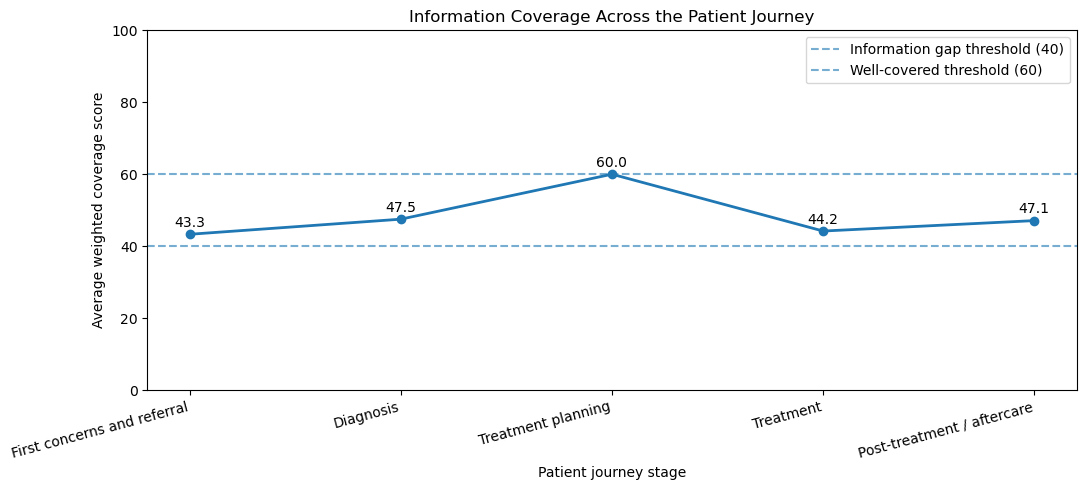

In [141]:
import matplotlib.pyplot as plt

# Plot average information coverage across the patient journey.

plot_data = journey_stage_summary.copy()

plt.figure(figsize=(11, 5))

plt.plot(
    plot_data["journey_stage"].astype(str),
    plot_data["average_coverage_score"],
    marker="o",
    linewidth=2
)

# Add coverage thresholds.
plt.axhline(
    y=40,
    linestyle="--",
    alpha=0.6,
    label="Information gap threshold (40)"
)

plt.axhline(
    y=60,
    linestyle="--",
    alpha=0.6,
    label="Well-covered threshold (60)"
)

# Add score labels.
for i, score in enumerate(plot_data["average_coverage_score"]):
    plt.text(
        i,
        score + 2,
        f"{score:.1f}",
        ha="center"
    )

plt.title("Information Coverage Across the Patient Journey")
plt.xlabel("Patient journey stage")
plt.ylabel("Average weighted coverage score")

plt.ylim(0, 100)
plt.xticks(rotation=15, ha="right")
plt.legend()
plt.tight_layout()

plt.show()

### Interpretation and Implications for Patients

The patient journey analysis shows that information coverage varies substantially across the different stages of the cancer journey.

**Treatment planning is the strongest stage**, reaching an average coverage score of 60.0. Patients are therefore relatively more likely to find sufficient information when making decisions about their treatment.

However, coverage drops considerably during **treatment**, to an average score of 44.2. This suggests that once treatment begins, patients may struggle to find sufficiently complete information about practical issues, support services and what to expect during this phase.

Information is also relatively limited at the **beginning of the journey**. First concerns and referral have an average score of 43.3, which may create uncertainty for patients about how to enter the Dutch healthcare system, where to go and what to expect next.

Finally, coverage remains limited after treatment, with **post-treatment and aftercare** reaching only 47.1. This may leave patients with insufficient guidance when transitioning back to everyday life or looking for longer-term support.

Overall, the analysis suggests that information is not consistently available throughout the patient journey. The main opportunity for CSN is therefore not only to provide more information, but to ensure that patients can access the **right information at the right stage of their journey**, particularly during treatment and the transition into longer-term care.

# 8. Final Insights and Recommendations

## Bringing the Analysis Together

The purpose of this project was not only to measure how much cancer-related information is available in English, but to understand whether this information actually helps English-speaking patients navigate cancer care in the Netherlands.

Throughout the analysis, we therefore looked at the information landscape from three complementary perspectives, each answering a different question:

- **Question-level analysis:** *Can patients find answers to the specific questions they are likely to ask?*
- **Category-level analysis:** *Which broader areas of information are currently well covered, and where are the main weaknesses?*
- **Patient journey analysis:** *At which stages of the cancer journey are patients most likely to face information gaps?*

Looking at these three dimensions together provides a more complete picture. A patient does not experience information as a dataset or a list of websites. They experience it while trying to understand what is happening, make decisions, access care and know what to do next.

The final objective is therefore to translate the analytical results into practical priorities for CSN: **what information should be improved, when it matters most, and how CSN can make the existing information landscape easier for patients to navigate.**

## Key Findings and What They Mean for Patients

### 1. Some patient questions are much easier to answer than others

The question-level analysis was used to identify the specific questions for which patients can already find relatively strong information, as well as those where important gaps remain.

The results show particularly low coverage for questions related to English-speaking healthcare providers, fertility support, nutrition advice, expected waiting times and longer-term support.

For patients, these are not only missing pieces of information. They can affect practical decisions and create uncertainty about **where to seek care, what support is available, how long the process may take and what happens beyond medical treatment itself**.

### 2. Information gaps are concentrated in particular areas

The category-level analysis was used to understand whether individual gaps form broader patterns.

Insurance and patients' rights are relatively well covered, while support services, recovery and several aspects of the cancer journey show weaker coverage.

This suggests that patients may be able to find information about formal aspects of healthcare, while having more difficulty finding practical guidance about **living through cancer, accessing additional support and managing recovery**.

### 3. Information availability also changes throughout the patient journey

The patient journey analysis was added to answer a different question: *when are these information gaps most likely to affect patients?*

Treatment planning is the strongest stage in the current dataset, with an average coverage score of **60.0**. Coverage is considerably lower during first concerns and referral (**43.3**), treatment (**44.2**) and post-treatment / aftercare (**47.1**).

This matters because information needs change as patients move through care. At the beginning of the journey, limited information may make it harder to understand how to enter and navigate the healthcare system. During treatment, patients may need clearer guidance on support and practical options. After treatment, weaker information may leave patients less certain about recovery and longer-term support.

### 4. The main challenge is not simply that information does not exist

Across the analyses, a broader pattern emerges: useful information is available, but coverage is uneven and information is distributed across different organisations and sources.

For an English-speaking patient, the challenge may therefore be less about finding *any* information and more about finding **the right information, in English, from a trustworthy source, at the moment when it becomes relevant**.

This fragmentation increases the effort required from patients to navigate an already complex healthcare journey.

## Recommendations for CSN

The results suggest that CSN can create value not only by providing more information, but by making existing information easier to find, understand and navigate.

### 1. Prioritise the most important information gaps

CSN should first focus content development on the questions with the weakest coverage, particularly English-speaking healthcare providers, waiting times, fertility support, nutrition advice and longer-term support.

**Benefit for patients:** this would reduce uncertainty in areas where reliable information is currently more difficult to find and provide practical answers to questions that can directly affect their care and daily life.

### 2. Structure information around the patient journey

Information could be organised according to the main stages identified in the analysis: first concerns and referral, diagnosis, treatment planning, treatment and post-treatment / aftercare.

**Benefit for patients:** instead of searching through large amounts of information, patients could start from where they currently are in their journey and more easily understand what is relevant now and what may come next.

### 3. Combine journey stage with patient information needs

The category and patient journey analyses should be used together. Within each stage, patients could access relevant information on healthcare organisation, rights, insurance, support services and recovery.

**Benefit for patients:** this would create a more personalised navigation experience and reduce the need to understand the structure of the Dutch healthcare system before being able to find an answer.

### 4. Act as a navigator of trustworthy information

Where reliable information already exists, CSN does not necessarily need to recreate it. Instead, CSN can connect patients to relevant sources while explaining clearly why the information is useful and what action they may need to take next.

**Benefit for patients:** this could reduce fragmented searching across multiple organisations while maintaining access to authoritative information.

### 5. Treat the current analysis as a baseline

The coverage scores reflect the sources included in the current dataset and should not be interpreted as a complete measure of all cancer information available in the Netherlands.

As CSN expands its information base, the same analysis can be repeated to assess whether identified gaps are being reduced and whether new priorities emerge.

**Benefit for patients:** this creates a process through which the platform can continuously improve as new information and patient needs are identified.

## Conclusion

The analysis shows that improving access to cancer information is not only about increasing the amount of content available. It is also about helping patients find the right information at the right moment.

By analysing individual patient questions, broader information categories and the different stages of the patient journey, this project identifies **what information is difficult to find, where the main weaknesses are concentrated and when these gaps may affect patients most**.

For English-speaking cancer patients, better information navigation could mean less uncertainty about how the healthcare system works, clearer expectations about what happens next, easier access to available support and greater ability to make informed decisions throughout their journey.

For CSN, this provides a practical basis for deciding what to prioritise. Rather than attempting to reproduce all existing cancer information, CSN can focus on filling important gaps, connecting trustworthy sources and organising information around the real questions and stages experienced by patients.

The opportunity is therefore to transform a fragmented information landscape into a clearer and more patient-centred pathway: helping patients understand **where they are, what they need to know and where they can go next**.